# Modeling With processed_data

`processed_data` 폴더의 전처리 완료 CSV를 이용해 양품/불량 분류 모델을 학습하고 비교합니다.

사용 파일:
- `processed_data/df_final.csv`: 기본 전처리/파생변수 포함 데이터
- `processed_data/df_pad.csv`: pad 버전 데이터
- `processed_data/lr_cols.csv`: Logistic Regression용 컬럼 목록
- `processed_data/tree_cols.csv`: tree/boost 계열용 컬럼 목록
- `processed_data/tree_pad_cols.csv`: pad 데이터용 tree/boost 컬럼 목록

평가 지표:
- F1
- PR-AUC / Average Precision
- Precision, Recall
- ROC-AUC
- Balanced Accuracy

불량이 약 3%인 극심한 불균형 데이터이므로 accuracy보다 F1, PR-AUC, Recall/Precision 균형을 우선합니다.


In [1]:
import sys
print(sys.executable)
print(sys.version)

# 필요 패키지 예시:
# .venv/bin/pip install pandas numpy matplotlib seaborn scikit-learn joblib
# 선택 모델:
# .venv/bin/pip install imbalanced-learn xgboost lightgbm catboost pytorch-tabnet torch


/Users/yejinpark/Desktop/bigdata_project/.venv/bin/python
3.12.13 (main, Mar  3 2026, 12:39:30) [Clang 21.0.0 (clang-2100.0.123.102)]


In [2]:
from pathlib import Path
import importlib.util
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import OneClassSVM
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score, roc_auc_score, f1_score, precision_score, recall_score,
    balanced_accuracy_score, confusion_matrix, classification_report, precision_recall_curve
)

sns.set_theme(style='whitegrid', font='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd()
DATA_DIR = ROOT / 'processed_data'
OUT_DIR = ROOT / 'outputs_processed' / 'modeling'
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
RUN_HEAVY_MODELS = False  # TabNet 등 시간이 오래 걸리는 모델은 True로 바꿔 실행하세요.
TARGET_COL = 'judge'


## 1. 데이터 로드

In [3]:
df_final = pd.read_csv(DATA_DIR / 'df_final.csv')
df_pad = pd.read_csv(DATA_DIR / 'df_pad.csv')
lr_cols = pd.read_csv(DATA_DIR / 'lr_cols.csv').iloc[:, 0].dropna().tolist()
tree_cols = pd.read_csv(DATA_DIR / 'tree_cols.csv').iloc[:, 0].dropna().tolist()
tree_pad_cols = pd.read_csv(DATA_DIR / 'tree_pad_cols.csv').iloc[:, 0].dropna().tolist()

print('df_final:', df_final.shape)
print('df_pad:', df_pad.shape)
print('lr_cols:', len(lr_cols))
print('tree_cols:', len(tree_cols))
print('tree_pad_cols:', len(tree_pad_cols))

assert TARGET_COL in df_final.columns
assert TARGET_COL in df_pad.columns
assert set(lr_cols).issubset(df_final.columns)
assert set(tree_cols).issubset(df_final.columns)
assert set(tree_pad_cols).issubset(df_pad.columns)

print(df_final[TARGET_COL].value_counts())
print(df_final[TARGET_COL].value_counts(normalize=True))
df_final.head()


df_final: (38595, 142)
df_pad: (38595, 141)
lr_cols: 64
tree_cols: 134
tree_pad_cols: 134
judge
0    37377
1     1218
Name: count, dtype: int64
judge
0    0.968442
1    0.031558
Name: proportion, dtype: float64


,lot_id,tray_id,cell_id,dt_start,judge,rta1_cell_no,rta1_box_col,rta1_box_row,rta1_box_dan,hta1_box_col,...,date,weekday,ce1,ce2,c3_cc_ratio,c4_cc_ratio,m1_missing_flag,all_missing_flag,temp_mean,temp_bin
0,100,1023,10747,2025-09-01 10:01:25,0,10,8,33,8,3,...,2025-09-01,0,8.432801,87.040000,0.771696,0.950957,0,0,267.571429,"(263.543, 267.886]"
1,100,1023,10748,2025-09-01 10:01:25,0,7,8,33,8,3,...,2025-09-01,0,8.528951,82.800609,0.765625,0.952202,0,0,267.571429,"(263.543, 267.886]"
2,100,1023,10749,2025-09-01 10:01:25,0,19,8,33,8,3,...,2025-09-01,0,8.452455,86.349206,0.768924,0.950351,0,0,267.571429,"(263.543, 267.886]"
3,100,1023,10750,2025-09-01 10:01:25,0,24,8,33,8,3,...,2025-09-01,0,8.418289,86.762360,0.762092,0.950743,0,0,267.571429,"(263.543, 267.886]"
4,100,1023,10751,2025-09-01 10:01:25,0,17,8,33,8,3,...,2025-09-01,0,8.387296,88.743883,0.784447,0.953803,0,0,267.571429,"(263.543, 267.886]"


## 2. 모델 입력 세트 구성

이전 방식과 동일하게 LR용, tree/boost용, tree/boost pad용 입력을 따로 둡니다. 이미 processed_data에서 전처리가 되어 있지만, 모델 실행 안정성을 위해 결측/무한대는 median imputer로 한 번 더 처리합니다.

In [4]:
y = df_final[TARGET_COL].astype(int).copy()

X_lr_raw = df_final[lr_cols].replace([np.inf, -np.inf], np.nan).copy()
X_tree_raw = df_final[tree_cols].replace([np.inf, -np.inf], np.nan).copy()
X_tree_pad_raw = df_pad[tree_pad_cols].replace([np.inf, -np.inf], np.nan).copy()

for name, X in [('X_lr_raw', X_lr_raw), ('X_tree_raw', X_tree_raw), ('X_tree_pad_raw', X_tree_pad_raw)]:
    print(name, X.shape, 'missing:', int(X.isna().sum().sum()))

# 전체 데이터 기준 imputation은 기존 방식에 맞춘 처리입니다. feedback 버전처럼 split 이후 fit하지 않습니다.
def median_impute_frame(X):
    all_missing = X.columns[X.isna().all()].tolist()
    X2 = X.drop(columns=all_missing)
    imputer = SimpleImputer(strategy='median')
    X_imp = pd.DataFrame(imputer.fit_transform(X2), columns=X2.columns, index=X2.index)
    return X_imp, all_missing, imputer

X_lr, lr_all_missing, lr_imputer = median_impute_frame(X_lr_raw)
X_tree, tree_all_missing, tree_imputer = median_impute_frame(X_tree_raw)
X_tree_pad, tree_pad_all_missing, tree_pad_imputer = median_impute_frame(X_tree_pad_raw)

print('after imputation')
print('X_lr:', X_lr.shape, 'dropped all-missing:', lr_all_missing)
print('X_tree:', X_tree.shape, 'dropped all-missing:', tree_all_missing)
print('X_tree_pad:', X_tree_pad.shape, 'dropped all-missing:', tree_pad_all_missing)


X_lr_raw (38595, 64) missing: 408
X_tree_raw (38595, 134) missing: 618
X_tree_pad_raw (38595, 134) missing: 0
after imputation
X_lr: (38595, 64) dropped all-missing: []
X_tree: (38595, 134) dropped all-missing: []
X_tree_pad: (38595, 134) dropped all-missing: []


## 3. Stratified Train / Valid / Test Split

In [5]:
idx_train_valid, idx_test = train_test_split(
    y.index, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
idx_train, idx_valid = train_test_split(
    idx_train_valid, test_size=0.25, stratify=y.loc[idx_train_valid], random_state=RANDOM_STATE
)

for name, idx in [('train', idx_train), ('valid', idx_valid), ('test', idx_test)]:
    print(name, 'rows=', len(idx), 'defects=', int(y.loc[idx].sum()), 'defect_rate=', y.loc[idx].mean())


train rows= 23157 defects= 731 defect_rate= 0.03156712872997366
valid rows= 7719 defects= 243 defect_rate= 0.03148076175670424
test rows= 7719 defects= 244 defect_rate= 0.03161031221660837


## 4. 평가 함수

In [6]:
def find_best_threshold(y_true, score):
    precision, recall, thresholds = precision_recall_curve(y_true, score)
    if len(thresholds) == 0:
        return 0.5
    f1 = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    return float(thresholds[int(np.nanargmax(f1))])

def get_scores(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        s = model.decision_function(X)
        return (s - np.nanmin(s)) / max(np.nanmax(s) - np.nanmin(s), 1e-12)
    return model.predict(X).astype(float)

def metric_row(name, y_true, score, threshold):
    pred = (score >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    row = {
        'model': name,
        'threshold': threshold,
        'f1': f1_score(y_true, pred, zero_division=0),
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'pr_auc': average_precision_score(y_true, score),
        'balanced_accuracy': balanced_accuracy_score(y_true, pred),
        'tn': cm[0, 0], 'fp': cm[0, 1], 'fn': cm[1, 0], 'tp': cm[1, 1],
    }
    try:
        row['roc_auc'] = roc_auc_score(y_true, score)
    except Exception:
        row['roc_auc'] = np.nan
    return row

def get_matrix(data_key):
    if data_key == 'lr':
        return X_lr
    if data_key == 'tree_pad':
        return X_tree_pad
    return X_tree

def evaluate_supervised(name, model, data_key):
    X = get_matrix(data_key)
    X_tr, y_tr = X.loc[idx_train], y.loc[idx_train]
    X_va, y_va = X.loc[idx_valid], y.loc[idx_valid]
    X_te, y_te = X.loc[idx_test], y.loc[idx_test]

    fitted = clone(model)
    fitted.fit(X_tr, y_tr)
    valid_score = get_scores(fitted, X_va)
    threshold = find_best_threshold(y_va, valid_score)
    test_score = get_scores(fitted, X_te)
    row = metric_row(name, y_te, test_score, threshold)
    return row, fitted, test_score

def evaluate_oneclass(name, model, data_key):
    X = get_matrix(data_key)
    y_tr = y.loc[idx_train]
    normal_idx = y_tr[y_tr == 0].index
    fitted = clone(model)
    fitted.fit(X.loc[normal_idx])

    valid_score = -fitted.decision_function(X.loc[idx_valid])
    threshold = find_best_threshold(y.loc[idx_valid], valid_score)
    test_score = -fitted.decision_function(X.loc[idx_test])
    row = metric_row(name, y.loc[idx_test], test_score, threshold)
    return row, fitted, test_score


## 5. 모델 Registry

설치되지 않은 외부 패키지는 자동으로 skip합니다.

In [7]:
def has_pkg(pkg):
    return importlib.util.find_spec(pkg) is not None

models = []
models.append(('Dummy_stratified', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE), 'tree', 'supervised'))
models.append(('LogisticRegression_balanced', Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=3000, solver='lbfgs', random_state=RANDOM_STATE))
]), 'lr', 'supervised'))
models.extend([
    ('DecisionTree_balanced', DecisionTreeClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=20, random_state=RANDOM_STATE), 'tree', 'supervised'),
    ('RandomForest_balanced', RandomForestClassifier(n_estimators=400, class_weight='balanced_subsample', min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE), 'tree', 'supervised'),
    ('RandomForest_balanced_pad', RandomForestClassifier(n_estimators=400, class_weight='balanced_subsample', min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE), 'tree_pad', 'supervised'),
    ('ExtraTrees_balanced', ExtraTreesClassifier(n_estimators=400, class_weight='balanced', min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE), 'tree', 'supervised'),
    ('GradientBoosting', GradientBoostingClassifier(random_state=RANDOM_STATE), 'tree', 'supervised'),
])
models.append(('OneClassSVM_normal_only', Pipeline([
    ('scaler', StandardScaler()),
    ('clf', OneClassSVM(kernel='rbf', nu=0.035, gamma='scale'))
]), 'lr', 'oneclass'))

if has_pkg('imblearn'):
    from imblearn.ensemble import BalancedRandomForestClassifier, RUSBoostClassifier, EasyEnsembleClassifier
    models.extend([
        ('BalancedRandomForest', BalancedRandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1), 'tree', 'supervised'),
        ('RUSBoost', RUSBoostClassifier(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE), 'tree', 'supervised'),
        ('EasyEnsemble', EasyEnsembleClassifier(n_estimators=20, random_state=RANDOM_STATE, n_jobs=-1), 'tree', 'supervised'),
    ])
else:
    print('skip imbalanced-learn models: imblearn not installed')

if has_pkg('xgboost'):
    from xgboost import XGBClassifier
    scale_pos_weight = (y == 0).sum() / max((y == 1).sum(), 1)
    models.append(('XGBoost_weighted', XGBClassifier(
        n_estimators=500, max_depth=4, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8,
        objective='binary:logistic', eval_metric='aucpr', scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, n_jobs=-1
    ), 'tree', 'supervised'))
else:
    print('skip XGBoost: xgboost not installed')

if has_pkg('lightgbm'):
    from lightgbm import LGBMClassifier
    models.append(('LightGBM_balanced', LGBMClassifier(
        n_estimators=600, learning_rate=0.03, num_leaves=31, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
    ), 'tree', 'supervised'))
else:
    print('skip LightGBM: lightgbm not installed')

if has_pkg('catboost'):
    from catboost import CatBoostClassifier
    models.append(('CatBoost_balanced', CatBoostClassifier(
        iterations=600, learning_rate=0.03, depth=5, loss_function='Logloss', eval_metric='PRAUC',
        auto_class_weights='Balanced', random_seed=RANDOM_STATE, verbose=False, allow_writing_files=False
    ), 'tree', 'supervised'))
else:
    print('skip CatBoost: catboost not installed')

if RUN_HEAVY_MODELS and has_pkg('pytorch_tabnet'):
    from pytorch_tabnet.tab_model import TabNetClassifier
    models.append(('TabNet', TabNetClassifier(seed=RANDOM_STATE, verbose=0), 'tree', 'supervised'))
elif not RUN_HEAVY_MODELS:
    print('skip TabNet: RUN_HEAVY_MODELS=False')

print('models to run:', [m[0] for m in models])


skip TabNet: RUN_HEAVY_MODELS=False
models to run: ['Dummy_stratified', 'LogisticRegression_balanced', 'DecisionTree_balanced', 'RandomForest_balanced', 'RandomForest_balanced_pad', 'ExtraTrees_balanced', 'GradientBoosting', 'OneClassSVM_normal_only', 'BalancedRandomForest', 'RUSBoost', 'EasyEnsemble', 'XGBoost_weighted', 'LightGBM_balanced', 'CatBoost_balanced']


## 6. 모델 학습 및 성능 비교

In [8]:
results = []
fitted_models = {}
test_scores = {}

for name, model, data_key, mode in models:
    print()
    print(f'=== {name} ===')
    try:
        if mode == 'oneclass':
            row, fitted, score = evaluate_oneclass(name, model, data_key)
        else:
            row, fitted, score = evaluate_supervised(name, model, data_key)
        row['data_key'] = data_key
        results.append(row)
        fitted_models[name] = fitted
        test_scores[name] = score
        print({k: row[k] for k in ['f1', 'precision', 'recall', 'pr_auc', 'threshold']})
    except Exception as e:
        print('FAILED:', repr(e))
        results.append({'model': name, 'data_key': data_key, 'status': f'failed: {e}'})

results_df = pd.DataFrame(results)
results_sorted = results_df.sort_values(['pr_auc', 'f1'], ascending=False, na_position='last')
display(results_sorted)
results_sorted.to_csv(OUT_DIR / 'processed_model_performance_comparison.csv', index=False, encoding='utf-8-sig')
print('saved:', OUT_DIR / 'processed_model_performance_comparison.csv')



=== Dummy_stratified ===
{'f1': 0.06128343589099586, 'precision': 0.03161031221660837, 'recall': 1.0, 'pr_auc': 0.0315765880065453, 'threshold': 0.0}

=== LogisticRegression_balanced ===
{'f1': 0.24671052631578946, 'precision': 0.20604395604395603, 'recall': 0.3073770491803279, 'pr_auc': 0.231589280562161, 'threshold': 0.8272554475542128}

=== DecisionTree_balanced ===
{'f1': 0.6794625719769674, 'precision': 0.6389891696750902, 'recall': 0.7254098360655737, 'pr_auc': 0.6257082868323033, 'threshold': 0.9568159739543675}

=== RandomForest_balanced ===
{'f1': 0.6695278969957081, 'precision': 0.7027027027027027, 'recall': 0.639344262295082, 'pr_auc': 0.7206135240610516, 'threshold': 0.5169372669642744}

=== RandomForest_balanced_pad ===
{'f1': 0.6695278969957081, 'precision': 0.7027027027027027, 'recall': 0.639344262295082, 'pr_auc': 0.7206135240610516, 'threshold': 0.5169372669642744}

=== ExtraTrees_balanced ===
{'f1': 0.5783664459161147, 'precision': 0.6267942583732058, 'recall': 0.536

,model,threshold,f1,precision,recall,pr_auc,balanced_accuracy,tn,fp,fn,tp,roc_auc,data_key
12,LightGBM_balanced,0.678267,0.758893,0.732824,0.786885,0.844296,0.888760,7405,70,52,192,0.989767,tree
11,XGBoost_weighted,0.814835,0.733212,0.657980,0.827869,0.752471,0.906911,7370,105,42,202,0.985601,tree
6,GradientBoosting,0.267872,0.756567,0.660550,0.885246,0.747515,0.935198,7364,111,28,216,0.978308,tree
13,CatBoost_balanced,0.905190,0.719844,0.685185,0.758197,0.733738,0.873413,7390,85,59,185,0.986540,tree
3,RandomForest_balanced,0.516937,0.669528,0.702703,0.639344,0.720614,0.815257,7409,66,88,156,0.982517,tree
4,RandomForest_balanced_pad,0.516937,0.669528,0.702703,0.639344,0.720614,0.815257,7409,66,88,156,0.982517,tree_pad
8,BalancedRandomForest,0.752500,0.628803,0.622490,0.635246,0.673729,0.811335,7381,94,89,155,0.977669,tree
2,DecisionTree_balanced,0.956816,0.679463,0.638989,0.725410,0.625708,0.856016,7375,100,67,177,0.932296,tree
5,ExtraTrees_balanced,0.692239,0.578366,0.626794,0.536885,0.584055,0.763225,7397,78,113,131,0.962883,tree
10,EasyEnsemble,0.555024,0.449438,0.369393,0.573770,0.340487,0.770899,7236,239,104,140,0.929297,tree


saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/processed_model_performance_comparison.csv


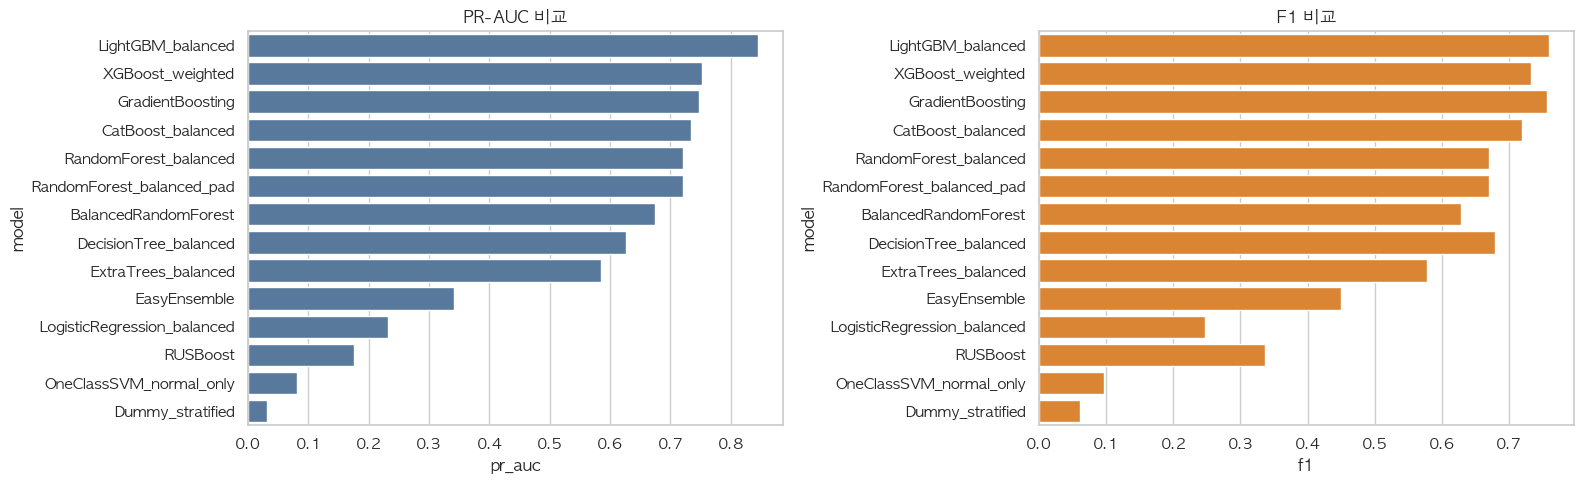

In [9]:
plot_df = results_sorted.dropna(subset=['f1', 'pr_auc']).copy()
if len(plot_df):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.barplot(data=plot_df, y='model', x='pr_auc', ax=axes[0], color='#4C78A8')
    axes[0].set_title('PR-AUC 비교')
    sns.barplot(data=plot_df, y='model', x='f1', ax=axes[1], color='#F58518')
    axes[1].set_title('F1 비교')
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'processed_model_metric_comparison.png', dpi=150)
    plt.show()


### 6-1. 모델별 설명변수 중요도 시각화

성능 비교 대상 모델별로 feature importance 또는 coefficient 기반 설명변수 그래프를 저장합니다.


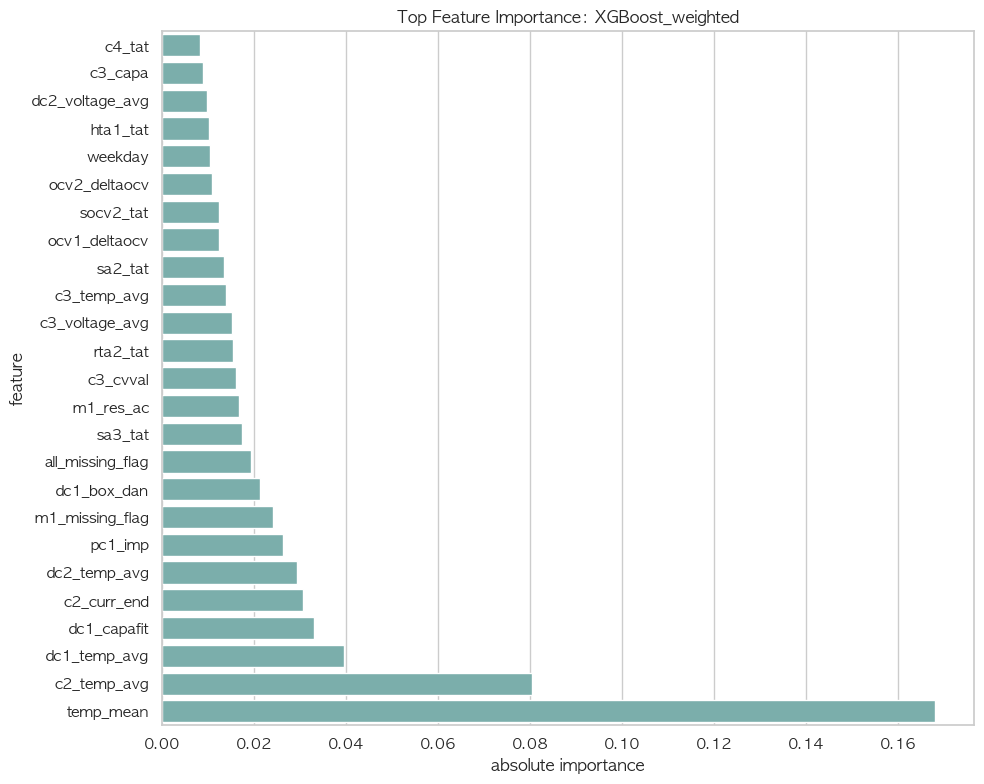

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/XGBoost_weighted_importance.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/XGBoost_weighted_feature_importance.png


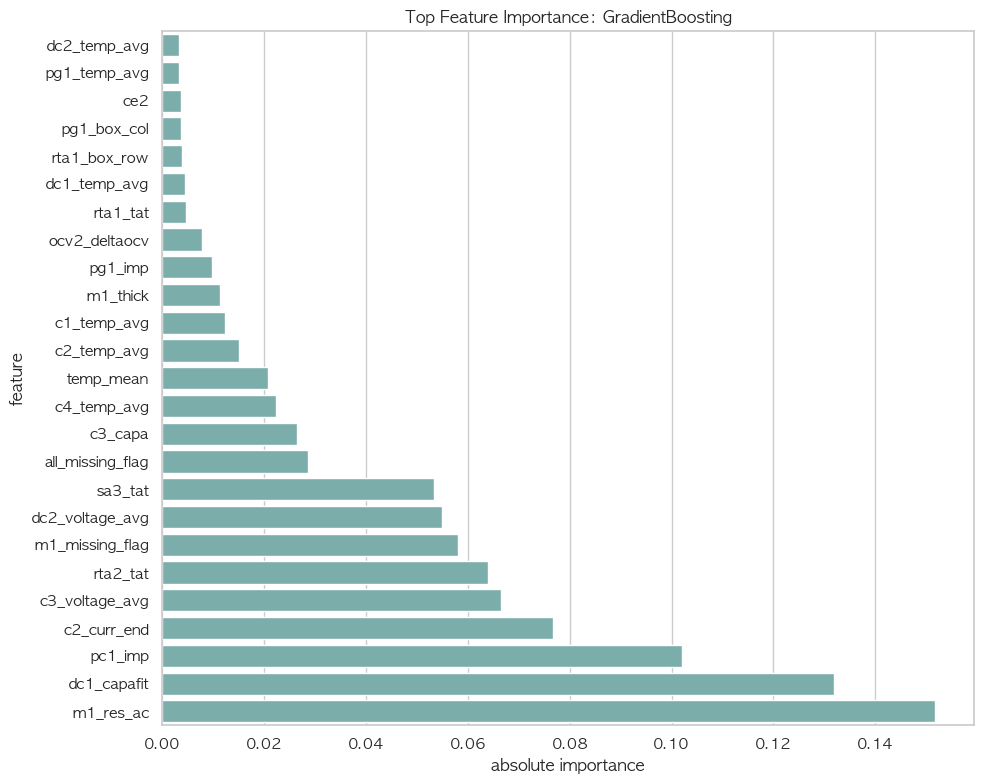

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/GradientBoosting_importance.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/GradientBoosting_feature_importance.png


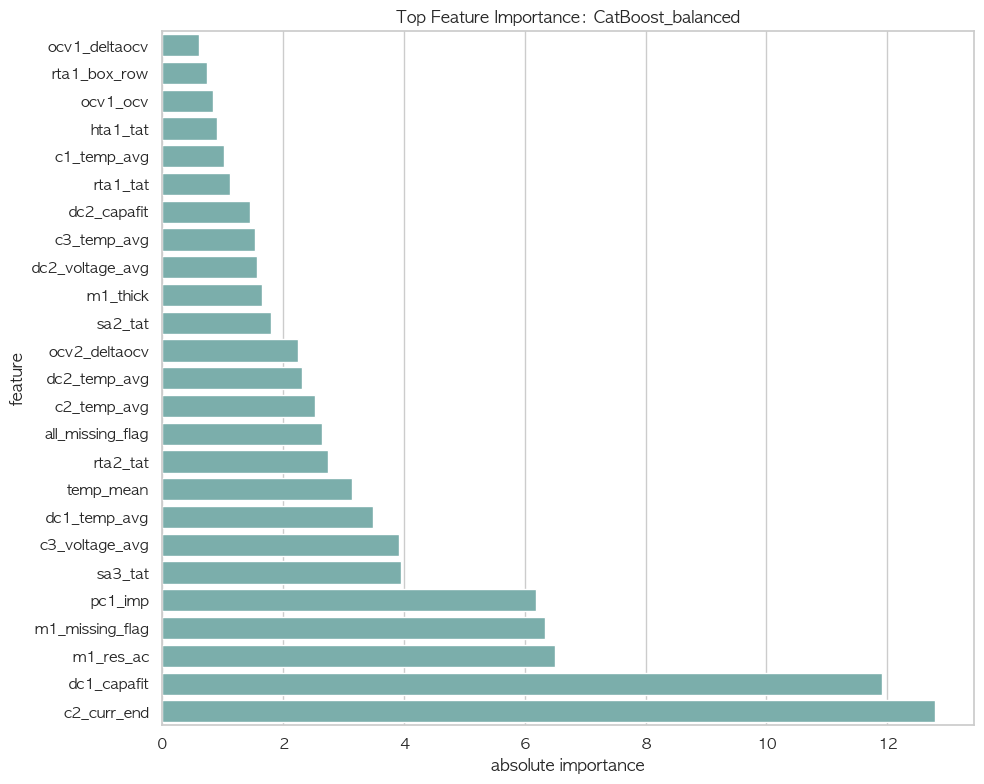

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/CatBoost_balanced_importance.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/CatBoost_balanced_feature_importance.png


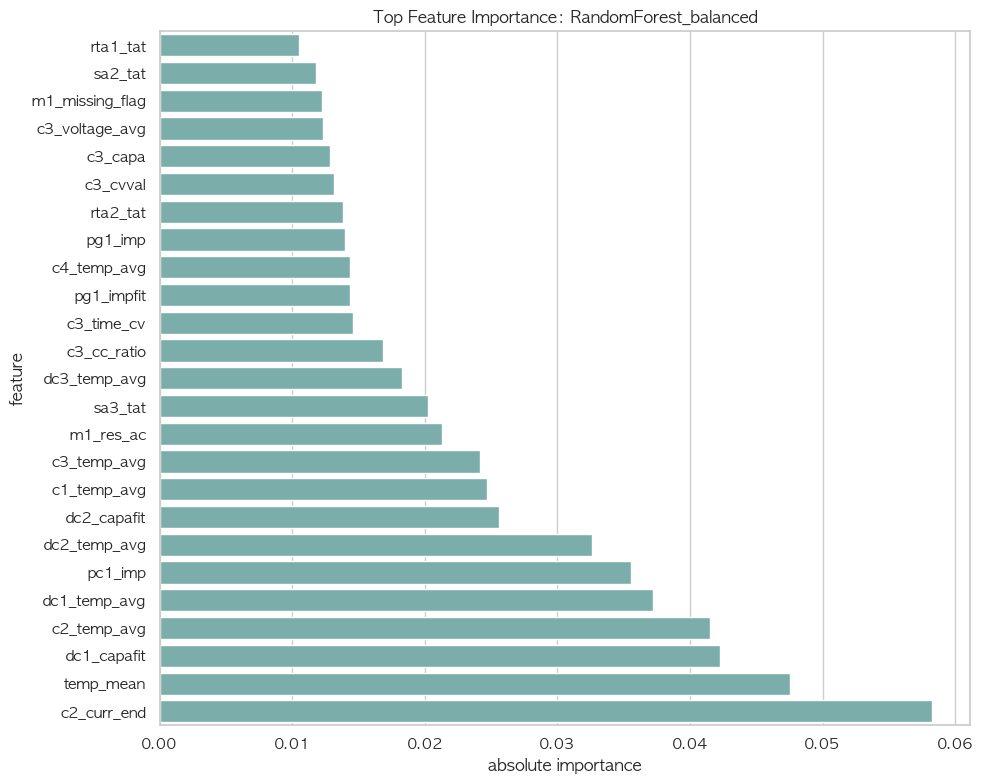

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/RandomForest_balanced_importance.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/RandomForest_balanced_feature_importance.png


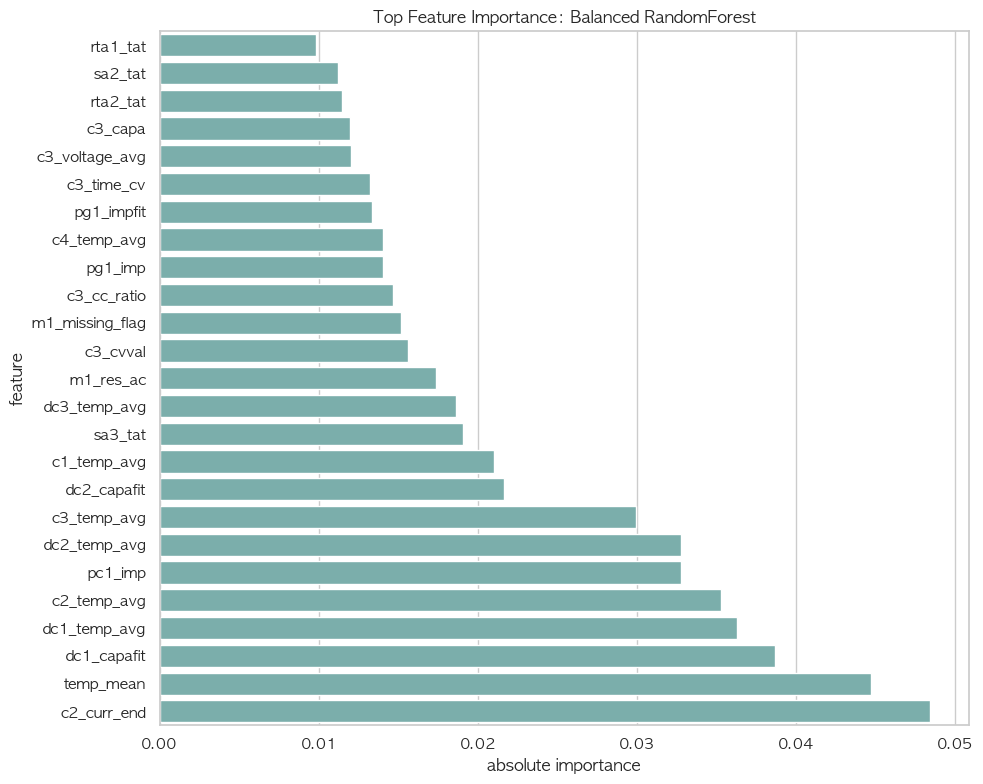

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/Balanced_RandomForest_importance.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/Balanced_RandomForest_feature_importance.png


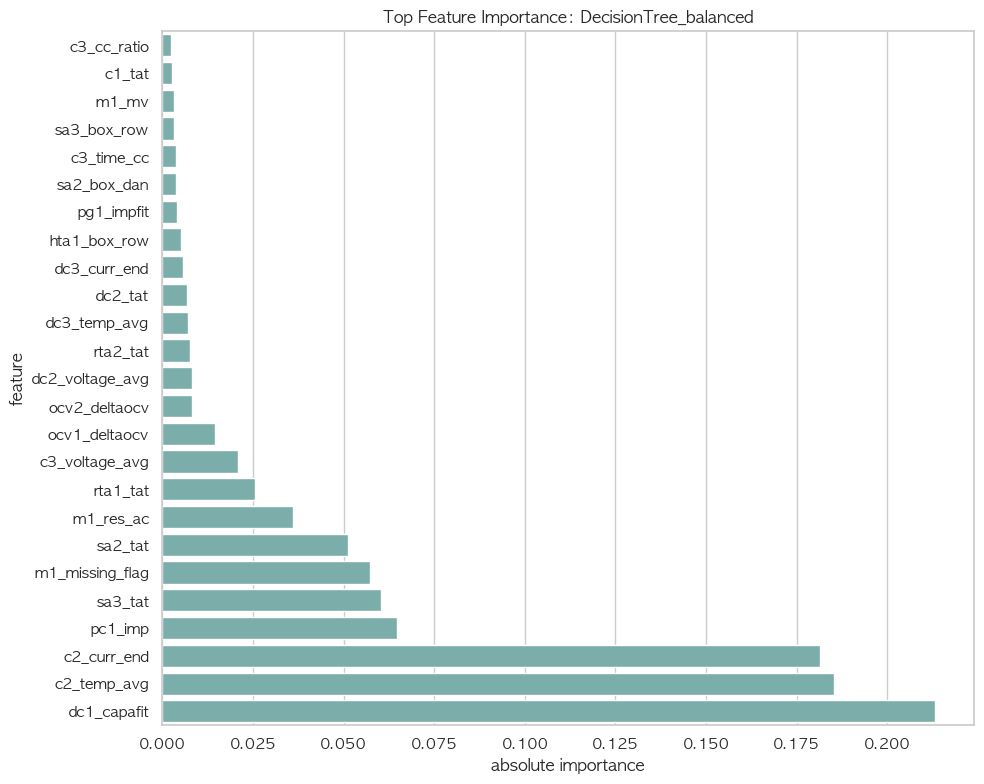

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/DecisionTree_balanced_importance.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/DecisionTree_balanced_feature_importance.png


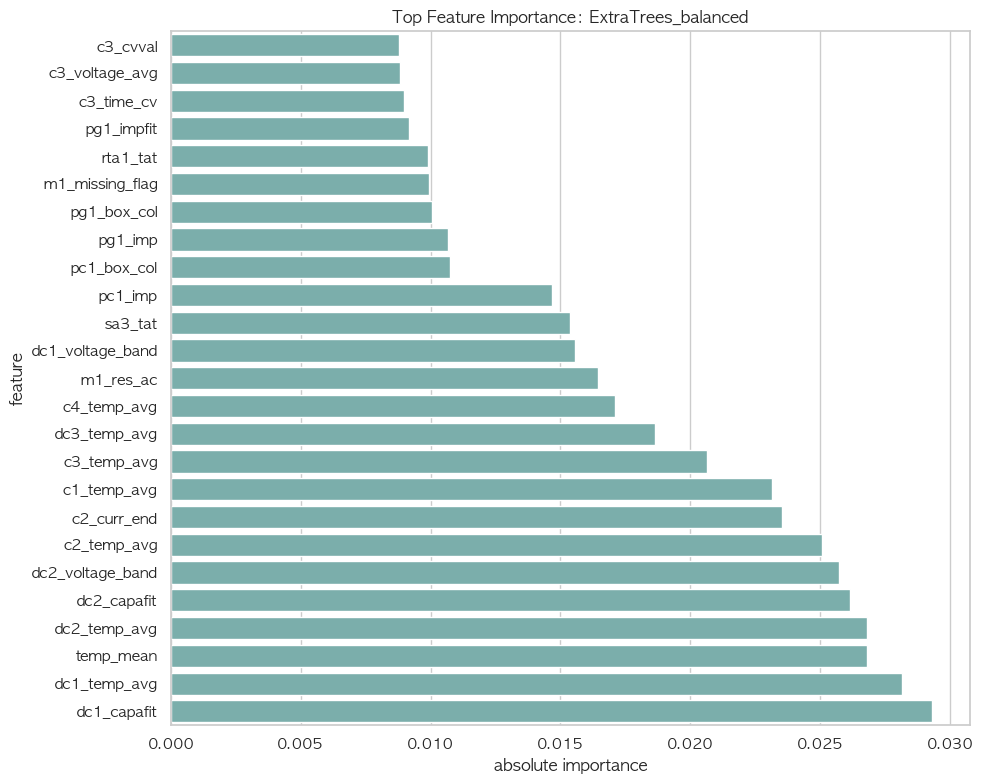

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/ExtraTrees_balanced_importance.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/ExtraTrees_balanced_feature_importance.png


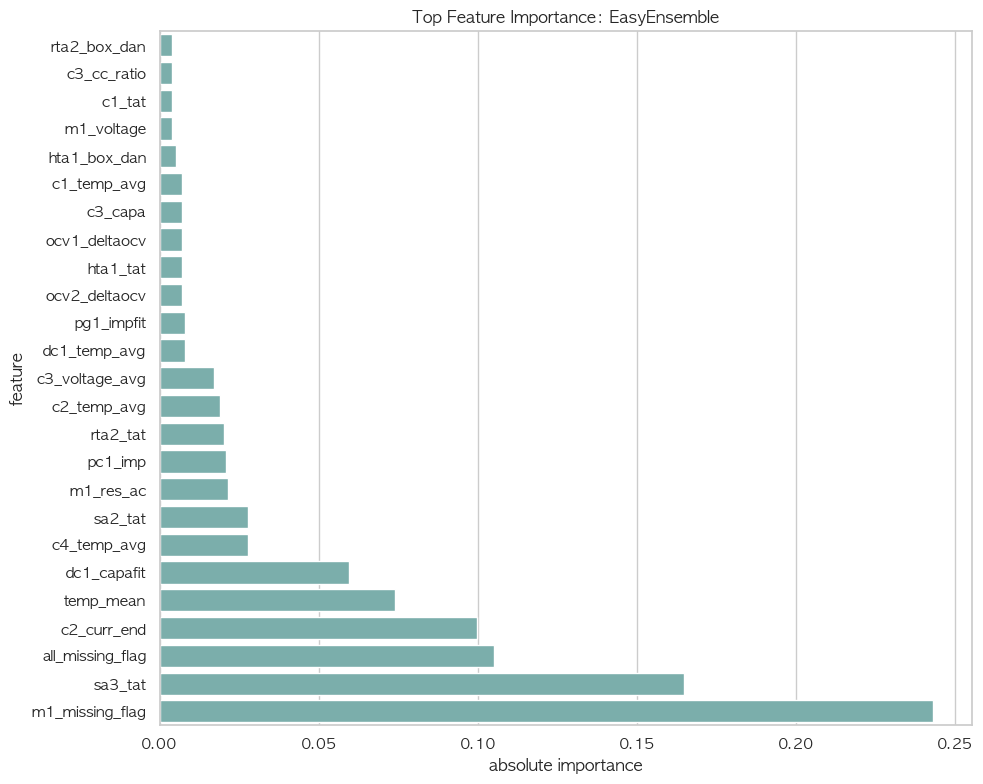

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/EasyEnsemble_importance.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/EasyEnsemble_feature_importance.png


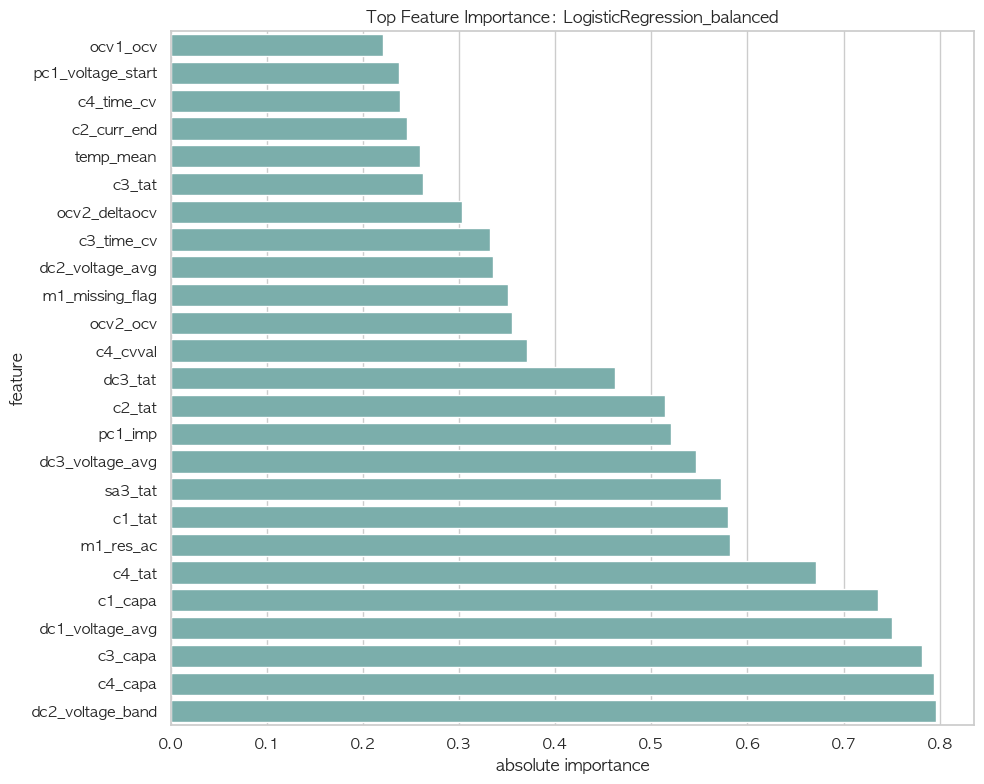

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/LogisticRegression_balanced_importance.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/LogisticRegression_balanced_feature_importance.png


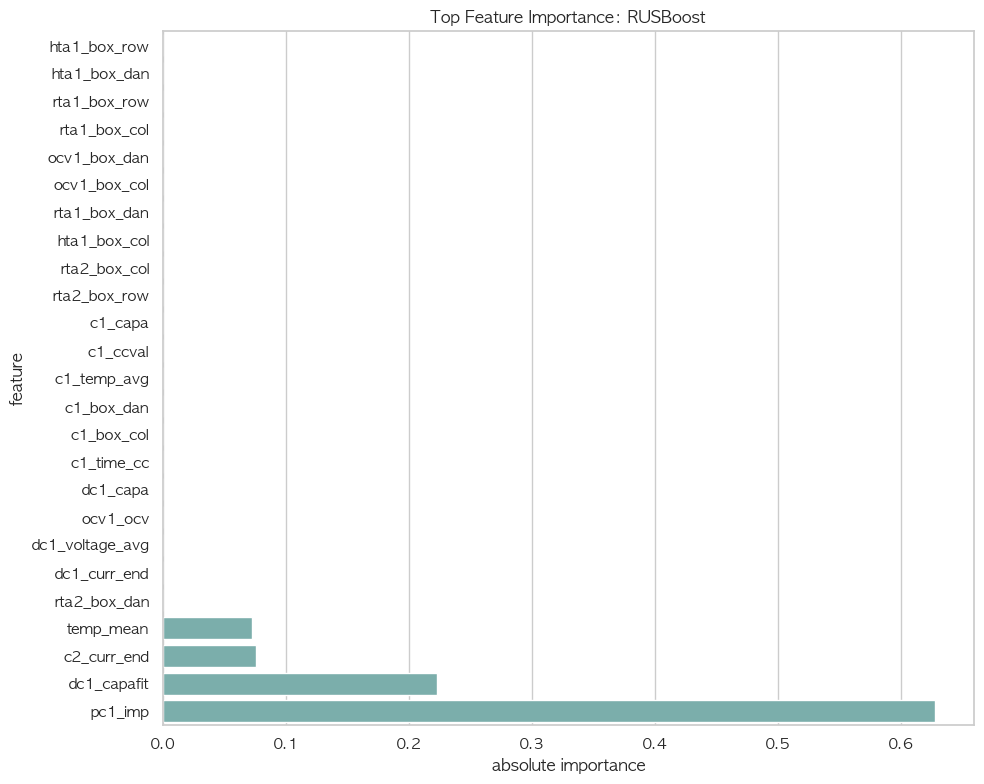

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/RUSBoost_importance.csv
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/RUSBoost_feature_importance.png


,model,data_key,feature,importance,abs_importance
0,XGBoost_weighted,tree,temp_mean,0.168062,0.168062
1,XGBoost_weighted,tree,c2_temp_avg,0.080460,0.080460
2,XGBoost_weighted,tree,dc1_temp_avg,0.039547,0.039547
3,XGBoost_weighted,tree,dc1_capafit,0.032966,0.032966
4,XGBoost_weighted,tree,c2_curr_end,0.030670,0.030670
...,...,...,...,...,...
1141,RUSBoost,tree,rta1_box_row,0.000000,0.000000
1142,RUSBoost,tree,hta1_box_dan,0.000000,0.000000
1143,RUSBoost,tree,hta1_box_row,0.000000,0.000000
1144,RUSBoost,tree,hta1_box_col,0.000000,0.000000


saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/all_model_feature_importance.csv


In [10]:
MODEL_NAMES_FOR_IMPORTANCE = [
    'XGBoost_weighted',
    'GradientBoosting',
    'CatBoost_balanced',
    'RandomForest_balanced',
    'Balanced RandomForest',
    'DecisionTree_balanced',
    'ExtraTrees_balanced',
    'EasyEnsemble',
    'LogisticRegression_balanced',
    'RUSBoost',
]

MODEL_NAME_ALIASES = {
    'Balanced RandomForest': 'BalancedRandomForest',
}

def _unwrap_estimator(model):
    if hasattr(model, 'named_steps'):
        return list(model.named_steps.values())[-1]
    return model

def _collect_importance_arrays(model):
    estimator = _unwrap_estimator(model)
    arrays = []

    if hasattr(estimator, 'feature_importances_'):
        arrays.append(np.asarray(estimator.feature_importances_, dtype=float))
    elif hasattr(estimator, 'coef_'):
        coef = np.asarray(estimator.coef_, dtype=float)
        if coef.ndim == 1:
            arrays.append(np.abs(coef))
        else:
            arrays.append(np.mean(np.abs(coef), axis=0))

    if hasattr(estimator, 'estimators_'):
        for sub_estimator in estimator.estimators_:
            arrays.extend(_collect_importance_arrays(sub_estimator))

    return arrays

def get_model_importance(model, feature_names):
    arrays = _collect_importance_arrays(model)
    valid_arrays = [arr for arr in arrays if len(arr) == len(feature_names)]
    if not valid_arrays:
        return None

    importance_values = np.mean(np.vstack(valid_arrays), axis=0)
    importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importance_values,
    })
    importance['abs_importance'] = importance['importance'].abs()
    return importance.sort_values('abs_importance', ascending=False)

def _safe_filename(name):
    return (str(name)
            .replace(' ', '_')
            .replace('/', '_')
            .replace('\\', '_')
            .replace(':', '_'))

all_importance_rows = []

for display_name in MODEL_NAMES_FOR_IMPORTANCE:
    model_name = MODEL_NAME_ALIASES.get(display_name, display_name)
    if model_name not in fitted_models:
        print(f'skip {display_name}: fitted_models에 학습 모델이 없습니다.')
        continue

    model_rows = results_df[results_df['model'] == model_name].dropna(subset=['data_key'])
    if len(model_rows) == 0:
        print(f'skip {display_name}: data_key 정보를 찾을 수 없습니다.')
        continue

    data_key = model_rows.iloc[0]['data_key']
    X_used = get_matrix(data_key)
    importance = get_model_importance(fitted_models[model_name], X_used.columns)

    if importance is None:
        print(f'skip {display_name}: feature_importances_ 또는 coef_를 추출할 수 없습니다.')
        continue

    importance.insert(0, 'model', display_name)
    importance.insert(1, 'data_key', data_key)
    all_importance_rows.append(importance)

    safe_name = _safe_filename(display_name)
    importance_path = OUT_DIR / f'{safe_name}_importance.csv'
    plot_path = OUT_DIR / f'{safe_name}_feature_importance.png'

    importance.to_csv(importance_path, index=False, encoding='utf-8-sig')

    top_imp = importance.head(25).sort_values('abs_importance')
    fig_height = max(6, 0.32 * len(top_imp))
    fig, ax = plt.subplots(figsize=(10, fig_height))
    sns.barplot(data=top_imp, x='abs_importance', y='feature', ax=ax, color='#72B7B2')
    ax.set_title(f'Top Feature Importance: {display_name}')
    ax.set_xlabel('absolute importance')
    ax.set_ylabel('feature')
    fig.tight_layout()
    fig.savefig(plot_path, dpi=150)
    plt.show()

    print('saved:', importance_path)
    print('saved:', plot_path)

if all_importance_rows:
    all_model_importance = pd.concat(all_importance_rows, ignore_index=True)
    all_model_importance.to_csv(OUT_DIR / 'all_model_feature_importance.csv', index=False, encoding='utf-8-sig')
    display(all_model_importance.groupby('model').head(10))
    print('saved:', OUT_DIR / 'all_model_feature_importance.csv')


## 7. Best Model 상세 확인

Excluded from automatic best selection: ['LightGBM']
Best model after exclusion: XGBoost_weighted
Data key: tree
Threshold: 0.8148353099822998
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      7475
          불량       0.66      0.83      0.73       244

    accuracy                           0.98      7719
   macro avg       0.83      0.91      0.86      7719
weighted avg       0.98      0.98      0.98      7719



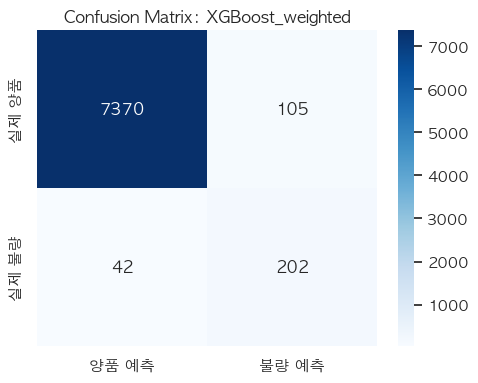

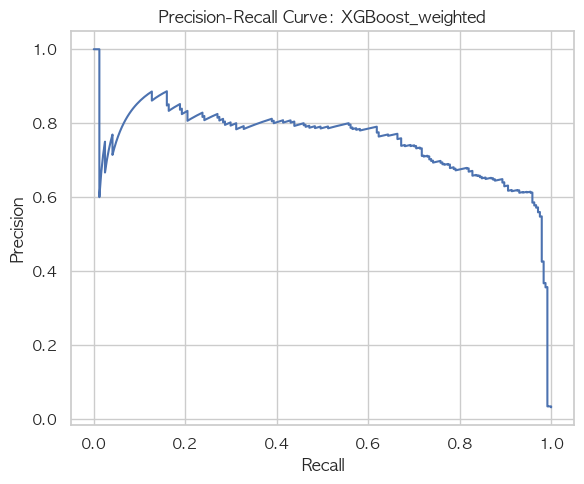

In [11]:
EXCLUDED_BEST_MODEL_PATTERNS = ['LightGBM']

valid_results = results_sorted.dropna(subset=['pr_auc', 'f1']).copy()
if len(valid_results):
    exclude_mask = valid_results['model'].astype(str).str.contains('|'.join(EXCLUDED_BEST_MODEL_PATTERNS), case=False, regex=True)
    best_candidate_results = valid_results[~exclude_mask].copy()

    if len(best_candidate_results) == 0:
        raise ValueError('LightGBM 제외 후 Best 후보 모델이 없습니다.')

    best_name = best_candidate_results.iloc[0]['model']
    best_threshold = float(best_candidate_results.iloc[0]['threshold'])
    best_score = test_scores[best_name]
    y_test = y.loc[idx_test]
    y_pred = (best_score >= best_threshold).astype(int)

    print('Excluded from automatic best selection:', EXCLUDED_BEST_MODEL_PATTERNS)
    print('Best model after exclusion:', best_name)
    print('Data key:', best_candidate_results.iloc[0].get('data_key'))
    print('Threshold:', best_threshold)
    print(classification_report(y_test, y_pred, target_names=['양품', '불량'], zero_division=0))

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['양품 예측','불량 예측'], yticklabels=['실제 양품','실제 불량'], ax=ax)
    ax.set_title(f'Confusion Matrix: {best_name}')
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'processed_best_model_confusion_matrix.png', dpi=150)
    plt.show()

    precision, recall, _ = precision_recall_curve(y_test, best_score)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(recall, precision)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Precision-Recall Curve: {best_name}')
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'processed_best_model_pr_curve.png', dpi=150)
    plt.show()


## 8. Feature Importance / Coefficient

,feature,importance,abs_importance
133,temp_mean,0.168062,0.168062
34,c2_temp_avg,0.080460,0.080460
25,dc1_temp_avg,0.039547,0.039547
26,dc1_capafit,0.032966,0.032966
27,c2_curr_end,0.030670,0.030670
40,dc2_temp_avg,0.029236,0.029236
79,pc1_imp,0.026153,0.026153
131,m1_missing_flag,0.024021,0.024021
24,dc1_box_dan,0.021252,0.021252
132,all_missing_flag,0.019293,0.019293


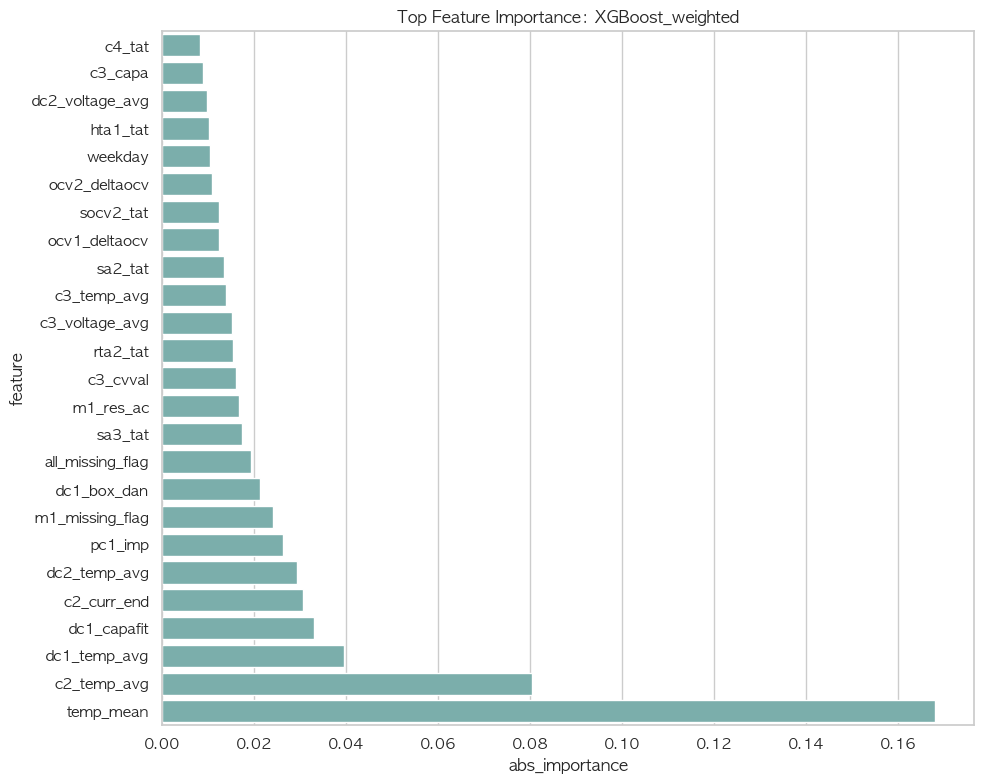

In [12]:
if len(valid_results):
    model = fitted_models[best_name]
    data_key = valid_results.iloc[0].get('data_key')
    X_used = get_matrix(data_key)
    feature_names = X_used.columns

    estimator = model.named_steps.get('clf', model) if hasattr(model, 'named_steps') else model
    importance = None
    if hasattr(estimator, 'feature_importances_'):
        importance = pd.DataFrame({'feature': feature_names, 'importance': estimator.feature_importances_})
    elif hasattr(estimator, 'coef_'):
        importance = pd.DataFrame({'feature': feature_names, 'importance': np.ravel(estimator.coef_)})

    if importance is not None:
        importance['abs_importance'] = importance['importance'].abs()
        importance = importance.sort_values('abs_importance', ascending=False)
        display(importance.head(30))
        importance.to_csv(OUT_DIR / f'{best_name}_importance.csv', index=False, encoding='utf-8-sig')

        fig, ax = plt.subplots(figsize=(10, 8))
        top_imp = importance.head(25).sort_values('abs_importance')
        sns.barplot(data=top_imp, x='abs_importance', y='feature', ax=ax, color='#72B7B2')
        ax.set_title(f'Top Feature Importance: {best_name}')
        fig.tight_layout()
        fig.savefig(OUT_DIR / 'processed_best_model_feature_importance.png', dpi=150)
        plt.show()
    else:
        print('선택된 best model은 importance/coefficient를 직접 제공하지 않습니다.')


## 9. Threshold Sensitivity

운영 목적에 맞게 Recall을 더 높이고 싶을 때 Precision/False Positive 변화를 확인하기 위한 표입니다.

In [13]:
if len(valid_results):
    y_test = y.loc[idx_test]
    threshold_grid = np.quantile(best_score, np.linspace(0.50, 0.99, 15))
    threshold_rows = []
    for th in sorted(set(threshold_grid)):
        threshold_rows.append(metric_row(best_name, y_test, best_score, float(th)))
    threshold_df = pd.DataFrame(threshold_rows).sort_values('threshold')
    display(threshold_df[['threshold', 'f1', 'precision', 'recall', 'pr_auc', 'fp', 'fn', 'tp', 'tn']])
    threshold_df.to_csv(OUT_DIR / 'processed_threshold_sensitivity.csv', index=False, encoding='utf-8-sig')


,threshold,f1,precision,recall,pr_auc,fp,fn,tp,tn
0,0.012902,0.117934,0.062694,0.991803,0.752471,3618,2,242,3857
1,0.014246,0.126272,0.067428,0.991803,0.752471,3347,2,242,4128
2,0.015701,0.135841,0.072914,0.991803,0.752471,3077,2,242,4398
3,0.017459,0.146978,0.079370,0.991803,0.752471,2807,2,242,4668
4,0.019370,0.160106,0.087082,0.991803,0.752471,2537,2,242,4938
5,0.022264,0.175808,0.096453,0.991803,0.752471,2267,2,242,5208
6,0.024960,0.194925,0.108084,0.991803,0.752471,1997,2,242,5478
7,0.028772,0.218708,0.122905,0.991803,0.752471,1727,2,242,5748
8,0.034436,0.249228,0.142521,0.991803,0.752471,1456,2,242,6019
9,0.042362,0.289474,0.169468,0.991803,0.752471,1186,2,242,6289


## 10. LightGBM Hyperparameter Optimization

기존 수동 설정 `LightGBM_balanced`와 별도로, 여러 하이퍼파라미터 조합을 학습해 validation 기준으로 최적 조합을 찾습니다.

방식:
- `ParameterSampler`로 후보 조합을 `N_ITER`개 샘플링합니다.
- 각 조합은 train set으로 학습합니다.
- validation set에서 PR-AUC, F1, precision, recall을 계산합니다.
- threshold는 각 조합별 validation F1이 최대가 되는 값으로 선택합니다.
- best 조합은 `valid_pr_auc` 1순위, `valid_f1` 2순위로 선택합니다.
- 선택된 best model만 test set에서 최종 평가합니다.


In [14]:
# # LightGBM 튜닝 설정
# # 실행 시간이 길면 N_ITER를 20 정도로 낮추고, 더 촘촘히 보고 싶으면 60~100으로 올리세요.
# from sklearn.model_selection import ParameterSampler

# if not has_pkg('lightgbm'):
#     raise ImportError('lightgbm이 설치되어 있지 않습니다. .venv/bin/pip install lightgbm 후 다시 실행하세요.')

# from lightgbm import LGBMClassifier

# N_ITER = 40
# LGBM_TUNING_RANDOM_STATE = RANDOM_STATE

# # 기존 데이터 구조에 맞춰 tree feature set 사용
# X_lgbm = X_tree
# X_train_lgbm, y_train_lgbm = X_lgbm.loc[idx_train], y.loc[idx_train]
# X_valid_lgbm, y_valid_lgbm = X_lgbm.loc[idx_valid], y.loc[idx_valid]
# X_test_lgbm, y_test_lgbm = X_lgbm.loc[idx_test], y.loc[idx_test]

# # 기존 manual LightGBM_balanced와 같은 설정을 0번 후보로 반드시 포함합니다.
# # 이렇게 해야 튜닝 결과가 baseline보다 좋아졌는지 같은 split/threshold 방식으로 공정하게 비교할 수 있습니다.
# manual_lgbm_params = {
#     'n_estimators': 600,
#     'learning_rate': 0.03,
#     'num_leaves': 31,
#     'max_depth': -1,
#     'min_child_samples': 20,
#     'subsample': 1.0,
#     'colsample_bytree': 1.0,
#     'reg_alpha': 0.0,
#     'reg_lambda': 0.0,
#     'min_split_gain': 0.0,
#     'class_weight': 'balanced',
# }

# param_distributions = {
#     'n_estimators': [300, 500, 600, 700, 1000, 1300],
#     'learning_rate': [0.01, 0.02, 0.03, 0.05, 0.08],
#     'num_leaves': [15, 31, 47, 63, 95],
#     'max_depth': [-1, 4, 6, 8, 10, 12],
#     'min_child_samples': [10, 20, 30, 50, 80, 120],
#     'subsample': [0.65, 0.75, 0.85, 0.95, 1.0],
#     'colsample_bytree': [0.65, 0.75, 0.85, 0.95, 1.0],
#     'reg_alpha': [0.0, 0.01, 0.05, 0.1, 0.5, 1.0],
#     'reg_lambda': [0.0, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0],
#     'min_split_gain': [0.0, 0.01, 0.05, 0.1],
#     'class_weight': ['balanced'],
# }

# sampled_params = list(ParameterSampler(
#     param_distributions,
#     n_iter=N_ITER,
#     random_state=LGBM_TUNING_RANDOM_STATE,
# ))

# # manual baseline을 맨 앞에 두고, 같은 조합이 random sample에 있으면 중복 제거합니다.
# def freeze_params(params):
#     return tuple(sorted(params.items()))

# seen = {freeze_params(manual_lgbm_params)}
# param_list = [manual_lgbm_params]
# for params in sampled_params:
#     key = freeze_params(params)
#     if key not in seen:
#         param_list.append(params)
#         seen.add(key)

# print('LightGBM tuning candidates including manual baseline:', len(param_list))
# print('candidate 000 is manual LightGBM_balanced baseline')
# print('train:', X_train_lgbm.shape, 'valid:', X_valid_lgbm.shape, 'test:', X_test_lgbm.shape)


In [15]:
# # LightGBM 후보 조합 학습 및 validation 평가
# lgbm_tuning_rows = []
# lgbm_tuned_models = {}

# for i, params in enumerate(param_list):
#     if i == 0:
#         model_name = 'LightGBM_manual_baseline'
#     else:
#         model_name = f'LightGBM_tuned_{i:03d}'
#     print(f'[{i:03d}/{len(param_list)-1:03d}] {model_name}: {params}')

#     model = LGBMClassifier(
#         **params,
#         objective='binary',
#         random_state=RANDOM_STATE,
#         n_jobs=-1,
#         verbosity=-1,
#     )

#     try:
#         model.fit(X_train_lgbm, y_train_lgbm)
#         valid_score = model.predict_proba(X_valid_lgbm)[:, 1]
#         threshold = find_best_threshold(y_valid_lgbm, valid_score)
#         valid_row = metric_row(model_name, y_valid_lgbm, valid_score, threshold)
#         valid_row = {f'valid_{k}': v for k, v in valid_row.items() if k != 'model'}

#         row = {
#             'model': model_name,
#             'is_manual_baseline': i == 0,
#             **params,
#             **valid_row,
#         }
#         lgbm_tuning_rows.append(row)
#         lgbm_tuned_models[model_name] = model
#         print({k: row[k] for k in ['valid_pr_auc', 'valid_f1', 'valid_precision', 'valid_recall', 'valid_threshold']})
#     except Exception as e:
#         print('FAILED:', repr(e))
#         row = {'model': model_name, 'is_manual_baseline': i == 0, **params, 'status': repr(e)}
#         lgbm_tuning_rows.append(row)

# lgbm_tuning_results = pd.DataFrame(lgbm_tuning_rows)
# lgbm_tuning_results = lgbm_tuning_results.sort_values(['valid_pr_auc', 'valid_f1'], ascending=False, na_position='last')
# display(lgbm_tuning_results.head(20))

# manual_result = lgbm_tuning_results[lgbm_tuning_results['is_manual_baseline'] == True]
# if len(manual_result):
#     print('Manual baseline rank:', int(lgbm_tuning_results.index.get_loc(manual_result.index[0]) + 1), '/', len(lgbm_tuning_results))
#     display(manual_result.T)

# lgbm_tuning_results.to_csv(OUT_DIR / 'lightgbm_tuning_results.csv', index=False, encoding='utf-8-sig')
# print('saved:', OUT_DIR / 'lightgbm_tuning_results.csv')


In [16]:
# # Validation 기준 best LightGBM을 test set에서 최종 평가
# valid_lgbm_results = lgbm_tuning_results.dropna(subset=['valid_pr_auc', 'valid_f1']).copy()
# if len(valid_lgbm_results) == 0:
#     raise ValueError('성공한 LightGBM 튜닝 결과가 없습니다.')

# best_lgbm_name = valid_lgbm_results.iloc[0]['model']
# best_lgbm_threshold = float(valid_lgbm_results.iloc[0]['valid_threshold'])
# best_lgbm_model = lgbm_tuned_models[best_lgbm_name]

# best_lgbm_test_score = best_lgbm_model.predict_proba(X_test_lgbm)[:, 1]
# best_lgbm_test_row = metric_row('LightGBM_tuned_best', y_test_lgbm, best_lgbm_test_score, best_lgbm_threshold)
# best_lgbm_test_df = pd.DataFrame([best_lgbm_test_row])

# display(valid_lgbm_results.head(1).T)
# display(best_lgbm_test_df)
# print('Best LightGBM params:')
# for k, v in best_lgbm_model.get_params().items():
#     if k in param_distributions or k in ['objective', 'random_state']:
#         print(f'{k}: {v}')

# best_lgbm_test_df.to_csv(OUT_DIR / 'lightgbm_tuned_best_test_report.csv', index=False, encoding='utf-8-sig')
# print('saved:', OUT_DIR / 'lightgbm_tuned_best_test_report.csv')


In [17]:
# # 튜닝 결과 시각화 및 best model 상세 리포트
# plot_tuning = valid_lgbm_results.head(20).copy()
# if len(plot_tuning):
#     fig, axes = plt.subplots(1, 2, figsize=(16, 6))
#     sns.barplot(data=plot_tuning, y='model', x='valid_pr_auc', ax=axes[0], color='#4C78A8')
#     axes[0].set_title('LightGBM tuning: validation PR-AUC Top 20')
#     sns.barplot(data=plot_tuning, y='model', x='valid_f1', ax=axes[1], color='#F58518')
#     axes[1].set_title('LightGBM tuning: validation F1 Top 20')
#     fig.tight_layout()
#     fig.savefig(OUT_DIR / 'lightgbm_tuning_top20_metrics.png', dpi=150)
#     plt.show()

# best_lgbm_pred = (best_lgbm_test_score >= best_lgbm_threshold).astype(int)
# print(classification_report(y_test_lgbm, best_lgbm_pred, target_names=['양품', '불량'], zero_division=0))

# cm = confusion_matrix(y_test_lgbm, best_lgbm_pred, labels=[0, 1])
# fig, ax = plt.subplots(figsize=(5, 4))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['양품 예측','불량 예측'], yticklabels=['실제 양품','실제 불량'], ax=ax)
# ax.set_title('Confusion Matrix: LightGBM_tuned_best')
# fig.tight_layout()
# fig.savefig(OUT_DIR / 'lightgbm_tuned_best_confusion_matrix.png', dpi=150)
# plt.show()

# precision, recall, _ = precision_recall_curve(y_test_lgbm, best_lgbm_test_score)
# fig, ax = plt.subplots(figsize=(6, 5))
# ax.plot(recall, precision)
# ax.set_xlabel('Recall')
# ax.set_ylabel('Precision')
# ax.set_title('PR Curve: LightGBM_tuned_best')
# fig.tight_layout()
# fig.savefig(OUT_DIR / 'lightgbm_tuned_best_pr_curve.png', dpi=150)
# plt.show()


In [18]:
# # Best tuned LightGBM feature importance
# lgbm_importance = pd.DataFrame({
#     'feature': X_train_lgbm.columns,
#     'importance': best_lgbm_model.feature_importances_,
# }).sort_values('importance', ascending=False)

# display(lgbm_importance.head(30))
# lgbm_importance.to_csv(OUT_DIR / 'lightgbm_tuned_best_importance.csv', index=False, encoding='utf-8-sig')

# fig, ax = plt.subplots(figsize=(10, 8))
# top_imp = lgbm_importance.head(25).sort_values('importance')
# sns.barplot(data=top_imp, x='importance', y='feature', ax=ax, color='#72B7B2')
# ax.set_title('Top Feature Importance: LightGBM_tuned_best')
# fig.tight_layout()
# fig.savefig(OUT_DIR / 'lightgbm_tuned_best_feature_importance.png', dpi=150)
# plt.show()


## 11. XGBoost Hyperparameter Optimization

최종 모델 후보를 XGBoost로 두고, 기존 `XGBoost_weighted` 수동 설정을 0번 후보로 포함한 뒤 validation PR-AUC/F1 기준으로 최적 조합을 선택합니다.


In [19]:
# XGBoost 튜닝 설정
from sklearn.model_selection import ParameterSampler

if not has_pkg('xgboost'):
    raise ImportError('xgboost가 설치되어 있지 않습니다. .venv/bin/pip install xgboost 후 다시 실행하세요.')

from xgboost import XGBClassifier

XGB_N_ITER = 40
XGB_TUNING_RANDOM_STATE = RANDOM_STATE

X_xgb = X_tree
X_train_xgb, y_train_xgb = X_xgb.loc[idx_train], y.loc[idx_train]
X_valid_xgb, y_valid_xgb = X_xgb.loc[idx_valid], y.loc[idx_valid]
X_test_xgb, y_test_xgb = X_xgb.loc[idx_test], y.loc[idx_test]

xgb_scale_pos_weight = (y_train_xgb == 0).sum() / max((y_train_xgb == 1).sum(), 1)

manual_xgb_params = {
    'n_estimators': 500,
    'max_depth': 4,
    'learning_rate': 0.03,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'gamma': 0.0,
    'reg_alpha': 0.0,
    'reg_lambda': 1.0,
    'scale_pos_weight': xgb_scale_pos_weight,
}

xgb_param_distributions = {
    'n_estimators': [300, 500, 700, 1000, 1300],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.02, 0.03, 0.05, 0.08],
    'subsample': [0.65, 0.75, 0.85, 0.95, 1.0],
    'colsample_bytree': [0.65, 0.75, 0.85, 0.95, 1.0],
    'min_child_weight': [1, 3, 5, 10, 20],
    'gamma': [0.0, 0.01, 0.05, 0.1, 0.3],
    'reg_alpha': [0.0, 0.01, 0.05, 0.1, 0.5],
    'reg_lambda': [0.5, 1.0, 1.5, 2.0, 3.0],
    'scale_pos_weight': [xgb_scale_pos_weight, xgb_scale_pos_weight * 0.75, xgb_scale_pos_weight * 1.25],
}

sampled_xgb_params = list(ParameterSampler(
    xgb_param_distributions,
    n_iter=XGB_N_ITER,
    random_state=XGB_TUNING_RANDOM_STATE,
))

def freeze_params(params):
    return tuple(sorted(params.items()))

seen = {freeze_params(manual_xgb_params)}
xgb_param_list = [manual_xgb_params]
for params in sampled_xgb_params:
    key = freeze_params(params)
    if key not in seen:
        xgb_param_list.append(params)
        seen.add(key)

print('XGBoost tuning candidates including manual baseline:', len(xgb_param_list))
print('candidate 000 is manual XGBoost_weighted baseline')
print('scale_pos_weight baseline:', xgb_scale_pos_weight)
print('train:', X_train_xgb.shape, 'valid:', X_valid_xgb.shape, 'test:', X_test_xgb.shape)


XGBoost tuning candidates including manual baseline: 41
candidate 000 is manual XGBoost_weighted baseline
scale_pos_weight baseline: 30.678522571819425
train: (23157, 134) valid: (7719, 134) test: (7719, 134)


In [20]:
# XGBoost 후보 조합 학습 및 validation 평가
xgb_tuning_rows = []
xgb_tuned_models = {}

for i, params in enumerate(xgb_param_list):
    if i == 0:
        model_name = 'XGBoost_manual_baseline'
    else:
        model_name = f'XGBoost_tuned_{i:03d}'
    print(f'[{i:03d}/{len(xgb_param_list)-1:03d}] {model_name}: {params}')

    model = XGBClassifier(
        **params,
        objective='binary:logistic',
        eval_metric='aucpr',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method='hist',
    )

    try:
        model.fit(X_train_xgb, y_train_xgb)
        valid_score = model.predict_proba(X_valid_xgb)[:, 1]
        threshold = find_best_threshold(y_valid_xgb, valid_score)
        valid_row = metric_row(model_name, y_valid_xgb, valid_score, threshold)
        valid_row = {f'valid_{k}': v for k, v in valid_row.items() if k != 'model'}

        row = {
            'model': model_name,
            'is_manual_baseline': i == 0,
            **params,
            **valid_row,
        }
        xgb_tuning_rows.append(row)
        xgb_tuned_models[model_name] = model
        print({k: row[k] for k in ['valid_pr_auc', 'valid_f1', 'valid_precision', 'valid_recall', 'valid_threshold']})
    except Exception as e:
        print('FAILED:', repr(e))
        row = {'model': model_name, 'is_manual_baseline': i == 0, **params, 'status': repr(e)}
        xgb_tuning_rows.append(row)

xgb_tuning_results = pd.DataFrame(xgb_tuning_rows)
xgb_tuning_results = xgb_tuning_results.sort_values(['valid_pr_auc', 'valid_f1'], ascending=False, na_position='last')
display(xgb_tuning_results.head(20))

manual_xgb_result = xgb_tuning_results[xgb_tuning_results['is_manual_baseline'] == True]
if len(manual_xgb_result):
    print('Manual XGBoost baseline rank:', int(xgb_tuning_results.index.get_loc(manual_xgb_result.index[0]) + 1), '/', len(xgb_tuning_results))
    display(manual_xgb_result.T)

xgb_tuning_results.to_csv(OUT_DIR / 'xgboost_tuning_results.csv', index=False, encoding='utf-8-sig')
print('saved:', OUT_DIR / 'xgboost_tuning_results.csv')


[000/040] XGBoost_manual_baseline: {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0.0, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'scale_pos_weight': np.float64(30.678522571819425)}
{'valid_pr_auc': 0.7487579491699783, 'valid_f1': 0.7649122807017544, 'valid_precision': 0.6666666666666666, 'valid_recall': 0.897119341563786, 'valid_threshold': 0.8148037791252136}
[001/040] XGBoost_tuned_001: {'subsample': 0.95, 'scale_pos_weight': np.float64(23.008891928864568), 'reg_lambda': 3.0, 'reg_alpha': 0.5, 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.02, 'gamma': 0.05, 'colsample_bytree': 0.75}
{'valid_pr_auc': 0.6890228048846421, 'valid_f1': 0.7542662116040956, 'valid_precision': 0.6443148688046647, 'valid_recall': 0.9094650205761317, 'valid_threshold': 0.7956123948097229}
[002/040] XGBoost_tuned_002: {'subsample': 0.85, 'scale_pos_weight': np.float64(23.008891928864568), 'reg_l

,model,is_manual_baseline,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,gamma,reg_alpha,...,valid_f1,valid_precision,valid_recall,valid_pr_auc,valid_balanced_accuracy,valid_tn,valid_fp,valid_fn,valid_tp,valid_roc_auc
13,XGBoost_tuned_013,False,1300,6,0.05,1.00,1.00,5,0.10,0.01,...,0.789784,0.755639,0.827160,0.818400,0.909233,7411,65,42,201,0.985871
2,XGBoost_tuned_002,False,1000,8,0.02,0.85,0.95,1,0.10,0.50,...,0.775735,0.700997,0.868313,0.815346,0.928137,7386,90,32,211,0.986078
4,XGBoost_tuned_004,False,1000,6,0.03,1.00,0.75,3,0.30,0.10,...,0.791822,0.722034,0.876543,0.812853,0.932787,7394,82,30,213,0.984586
33,XGBoost_tuned_033,False,300,8,0.08,1.00,0.85,5,0.10,0.01,...,0.774074,0.703704,0.860082,0.809666,0.924156,7388,88,34,209,0.987349
19,XGBoost_tuned_019,False,700,8,0.02,0.85,0.75,10,0.00,0.01,...,0.785080,0.690625,0.909465,0.808717,0.948111,7377,99,22,221,0.988739
25,XGBoost_tuned_025,False,1300,5,0.03,0.75,1.00,5,0.30,0.50,...,0.778598,0.705686,0.868313,0.804169,0.928271,7388,88,32,211,0.984760
40,XGBoost_tuned_040,False,300,8,0.02,0.95,0.85,1,0.00,0.10,...,0.766423,0.688525,0.864198,0.800837,0.925745,7381,95,33,210,0.988124
35,XGBoost_tuned_035,False,500,8,0.08,0.75,1.00,1,0.01,0.50,...,0.773547,0.753906,0.794239,0.799371,0.892906,7413,63,50,193,0.989000
17,XGBoost_tuned_017,False,500,8,0.02,0.95,0.65,5,0.10,0.01,...,0.779964,0.689873,0.897119,0.797740,0.942005,7378,98,25,218,0.988508
23,XGBoost_tuned_023,False,500,8,0.03,0.75,0.75,5,0.00,0.01,...,0.772809,0.683544,0.888889,0.797458,0.937756,7376,100,27,216,0.987368


Manual XGBoost baseline rank: 30 / 41


,0
model,XGBoost_manual_baseline
is_manual_baseline,True
n_estimators,500
max_depth,4
learning_rate,0.03
subsample,0.8
colsample_bytree,0.8
min_child_weight,1
gamma,0.0
reg_alpha,0.0


saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/xgboost_tuning_results.csv


,13
model,XGBoost_tuned_013
is_manual_baseline,False
n_estimators,1300
max_depth,6
learning_rate,0.05
subsample,1.0
colsample_bytree,1.0
min_child_weight,5
gamma,0.1
reg_alpha,0.01


,model,threshold,f1,precision,recall,pr_auc,balanced_accuracy,tn,fp,fn,tp,roc_auc
0,XGBoost_tuned_best,0.638813,0.756436,0.731801,0.782787,0.82407,0.886711,7405,70,53,191,0.988841


Best XGBoost params:
objective: binary:logistic
colsample_bytree: 1.0
eval_metric: aucpr
gamma: 0.1
learning_rate: 0.05
max_depth: 6
min_child_weight: 5
n_estimators: 1300
random_state: 42
reg_alpha: 0.01
reg_lambda: 2.0
scale_pos_weight: 38.34815321477428
subsample: 1.0
tree_method: hist
saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/xgboost_tuned_best_test_report.csv
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      7475
          불량       0.73      0.78      0.76       244

    accuracy                           0.98      7719
   macro avg       0.86      0.89      0.87      7719
weighted avg       0.98      0.98      0.98      7719



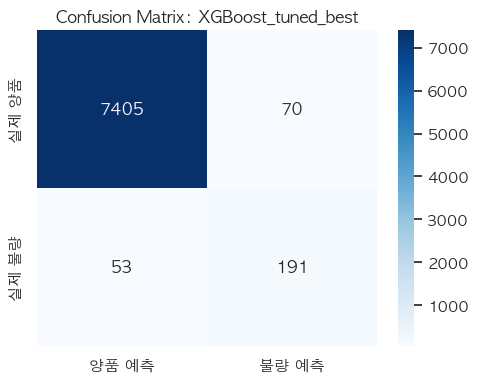

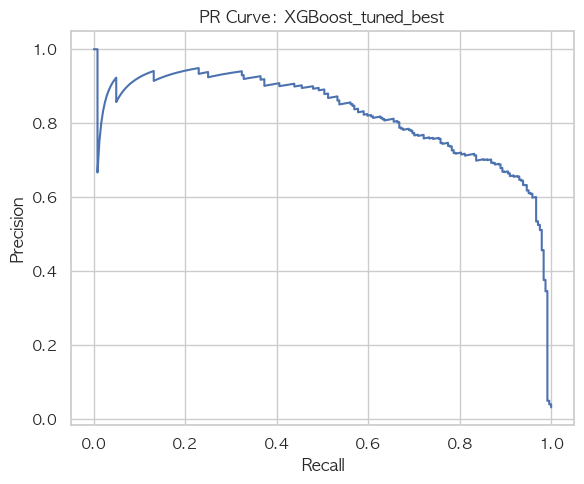

In [21]:
# Validation 기준 best XGBoost를 test set에서 최종 평가
valid_xgb_results = xgb_tuning_results.dropna(subset=['valid_pr_auc', 'valid_f1']).copy()
if len(valid_xgb_results) == 0:
    raise ValueError('성공한 XGBoost 튜닝 결과가 없습니다.')

best_xgb_name = valid_xgb_results.iloc[0]['model']
best_xgb_threshold = float(valid_xgb_results.iloc[0]['valid_threshold'])
best_xgb_model = xgb_tuned_models[best_xgb_name]

best_xgb_test_score = best_xgb_model.predict_proba(X_test_xgb)[:, 1]
best_xgb_test_row = metric_row('XGBoost_tuned_best', y_test_xgb, best_xgb_test_score, best_xgb_threshold)
best_xgb_test_df = pd.DataFrame([best_xgb_test_row])

display(valid_xgb_results.head(1).T)
display(best_xgb_test_df)
print('Best XGBoost params:')
for k, v in best_xgb_model.get_params().items():
    if k in xgb_param_distributions or k in ['objective', 'eval_metric', 'random_state', 'tree_method']:
        print(f'{k}: {v}')

best_xgb_test_df.to_csv(OUT_DIR / 'xgboost_tuned_best_test_report.csv', index=False, encoding='utf-8-sig')
print('saved:', OUT_DIR / 'xgboost_tuned_best_test_report.csv')

best_xgb_pred = (best_xgb_test_score >= best_xgb_threshold).astype(int)
print(classification_report(y_test_xgb, best_xgb_pred, target_names=['양품', '불량'], zero_division=0))

cm = confusion_matrix(y_test_xgb, best_xgb_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['양품 예측','불량 예측'], yticklabels=['실제 양품','실제 불량'], ax=ax)
ax.set_title('Confusion Matrix: XGBoost_tuned_best')
fig.tight_layout()
fig.savefig(OUT_DIR / 'xgboost_tuned_best_confusion_matrix.png', dpi=150)
plt.show()

precision, recall, _ = precision_recall_curve(y_test_xgb, best_xgb_test_score)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('PR Curve: XGBoost_tuned_best')
fig.tight_layout()
fig.savefig(OUT_DIR / 'xgboost_tuned_best_pr_curve.png', dpi=150)
plt.show()


In [25]:
!ps aux | grep brew

yejinpark        53524   0.0  0.0 33588448     96 s000  R+   12:29PM   0:00.00 grep brew
yejinpark        53522   0.0  0.0 33627500   1192 s000  Ss+  12:29PM   0:00.74 /bin/zsh -c ps aux | grep brew


In [28]:
!brew link graphviz

To relink, run:
  brew unlink graphviz && brew link graphviz


In [30]:
!which dot
!dot -V

/usr/local/bin/dot
dot - graphviz version 15.0.0 (20260523.1842)


,feature,importance,gain,weight,cover
133,temp_mean,0.226833,818.734131,141.0,2196.691162
34,c2_temp_avg,0.163427,589.876709,68.0,2036.168701
25,dc1_temp_avg,0.062751,226.492630,64.0,1429.517700
132,all_missing_flag,0.043068,155.450348,124.0,1611.579834
131,m1_missing_flag,0.038727,139.780289,275.0,1249.505005
27,c2_curr_end,0.038631,139.436035,735.0,755.860474
26,dc1_capafit,0.026427,95.385811,550.0,804.129517
43,c3_voltage_avg,0.016466,59.430889,280.0,354.885834
79,pc1_imp,0.016125,58.200645,732.0,387.881653
121,sa3_tat,0.015881,57.320431,483.0,440.453735


saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/xgboost_tuned_best_importance.csv


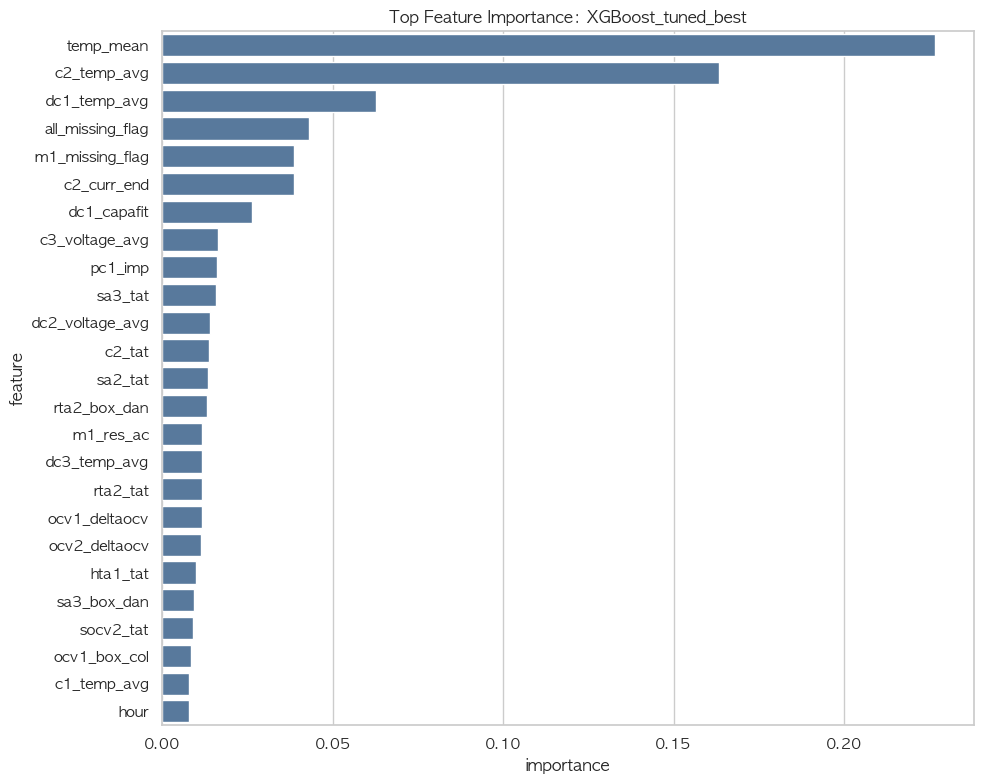

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/xgboost_tuned_best_feature_importance.png


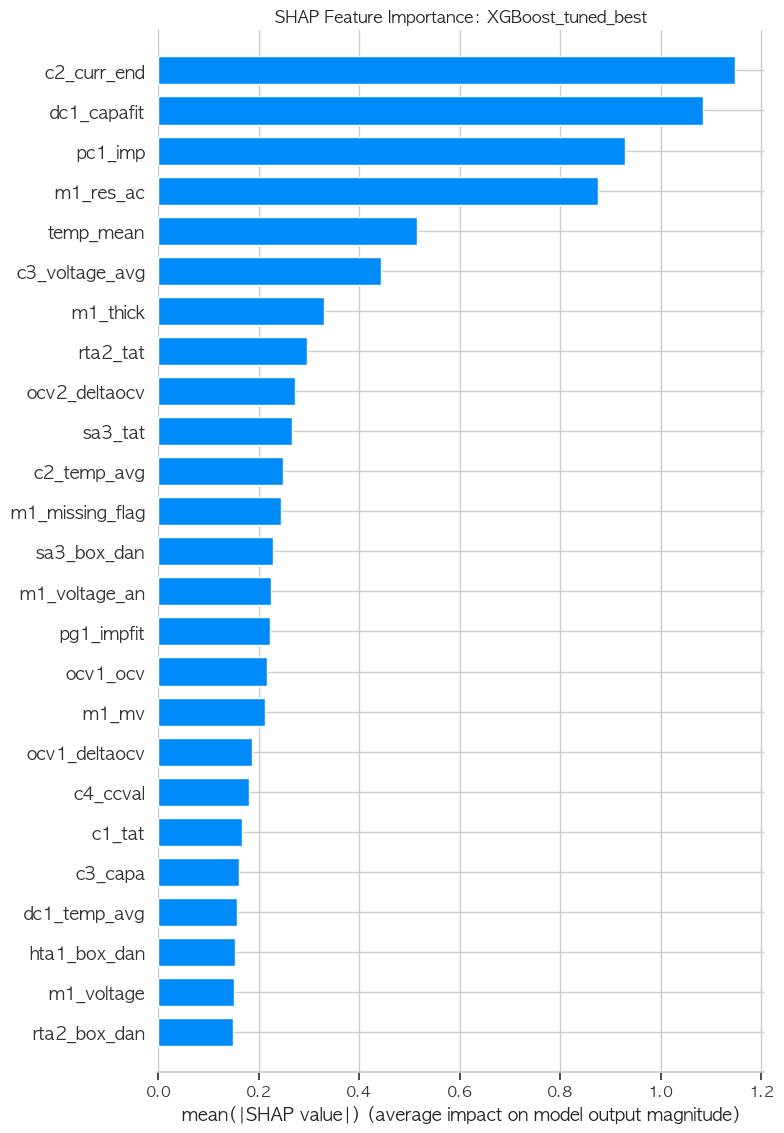

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/xgboost_tuned_best_shap_bar.png


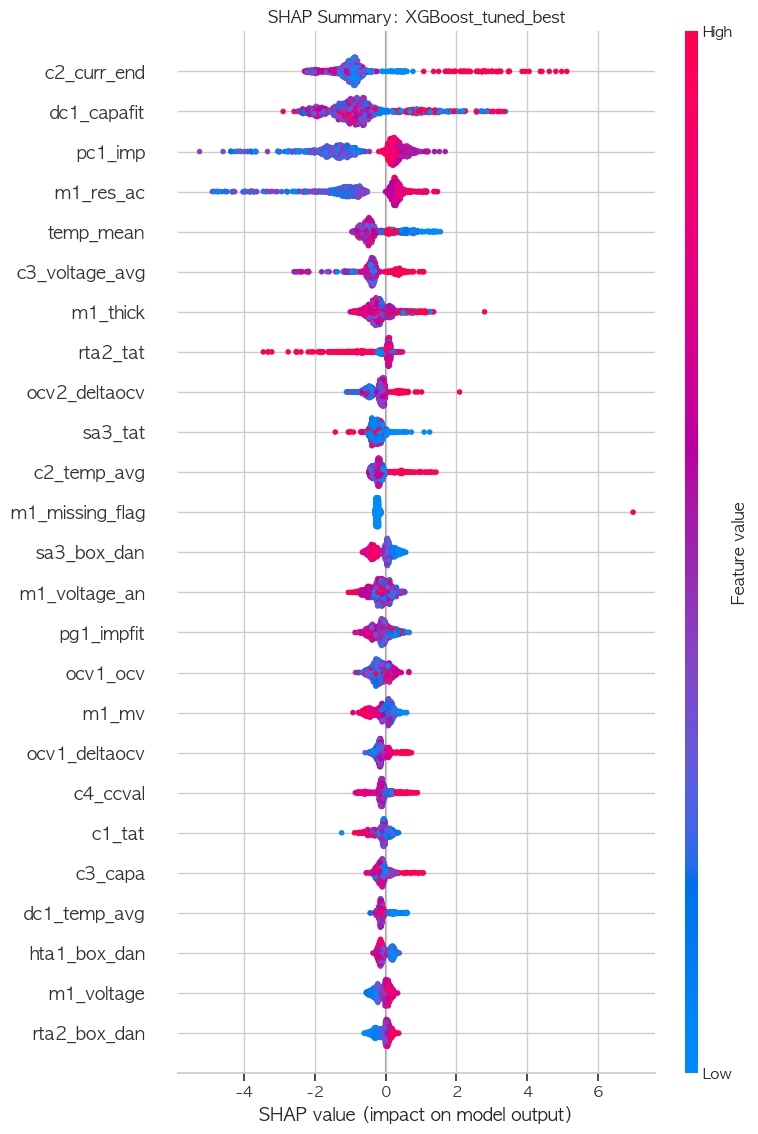

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/xgboost_tuned_best_shap_summary.png


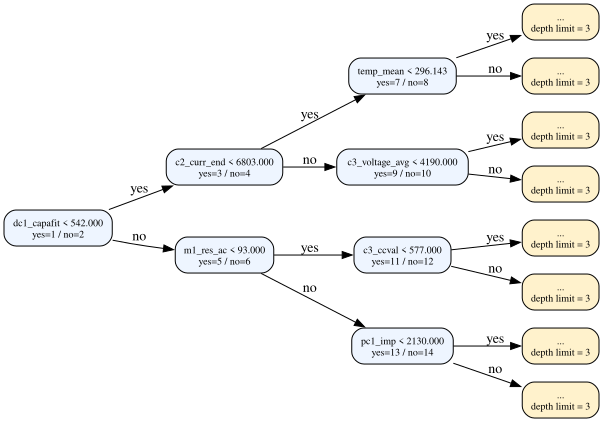

saved: /Users/yejinpark/Desktop/big_codex/outputs_processed/modeling/xgboost_tuned_best_tree_0_depth3.png


In [31]:
# Best tuned XGBoost feature importance, SHAP, and tree visualization
best_xgb_importance = pd.DataFrame({
    'feature': X_train_xgb.columns,
    'importance': best_xgb_model.feature_importances_,
})

xgb_booster = best_xgb_model.get_booster()
for importance_type in ['gain', 'weight', 'cover']:
    score_map = xgb_booster.get_score(importance_type=importance_type)
    best_xgb_importance[importance_type] = [
        score_map.get(feature, score_map.get(f'f{i}', 0.0))
        for i, feature in enumerate(X_train_xgb.columns)
    ]

best_xgb_importance = best_xgb_importance.sort_values('importance', ascending=False)
display(best_xgb_importance.head(30))
best_xgb_importance.to_csv(OUT_DIR / 'xgboost_tuned_best_importance.csv', index=False, encoding='utf-8-sig')
print('saved:', OUT_DIR / 'xgboost_tuned_best_importance.csv')

fig, ax = plt.subplots(figsize=(10, 8))
top_xgb_imp = best_xgb_importance.head(25).sort_values('importance', ascending=False)
sns.barplot(data=top_xgb_imp, x='importance', y='feature', ax=ax, color='#4C78A8', order=top_xgb_imp['feature'])
ax.set_title('Top Feature Importance: XGBoost_tuned_best')
fig.tight_layout()
fig.savefig(OUT_DIR / 'xgboost_tuned_best_feature_importance.png', dpi=150)
plt.show()
print('saved:', OUT_DIR / 'xgboost_tuned_best_feature_importance.png')

# SHAP 시각화: 설치되어 있지 않으면 건너뜁니다.
if has_pkg('shap'):
    import shap
    shap_sample_n = min(1000, len(X_test_xgb))
    X_shap_xgb = X_test_xgb.sample(n=shap_sample_n, random_state=RANDOM_STATE) if len(X_test_xgb) > shap_sample_n else X_test_xgb.copy()
    xgb_explainer = shap.TreeExplainer(best_xgb_model)
    xgb_shap_values = xgb_explainer.shap_values(X_shap_xgb)
    if isinstance(xgb_shap_values, list):
        xgb_shap_values = xgb_shap_values[-1]

    plt.figure(figsize=(10, 8))
    shap.summary_plot(xgb_shap_values, X_shap_xgb, plot_type='bar', show=False, max_display=25)
    plt.title('SHAP Feature Importance: XGBoost_tuned_best')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'xgboost_tuned_best_shap_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('saved:', OUT_DIR / 'xgboost_tuned_best_shap_bar.png')

    plt.figure(figsize=(10, 8))
    shap.summary_plot(xgb_shap_values, X_shap_xgb, show=False, max_display=25)
    plt.title('SHAP Summary: XGBoost_tuned_best')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'xgboost_tuned_best_shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('saved:', OUT_DIR / 'xgboost_tuned_best_shap_summary.png')
else:
    print('skip XGBoost SHAP: shap not installed')

# 발표용 XGBoost tree: 깊이를 제한해 저장합니다.
try:
    import json
    import shutil
    from graphviz import Digraph

    XGB_TREE_INDEX = 0
    XGB_MAX_DEPTH = 3
    tree_json = json.loads(best_xgb_model.get_booster().get_dump(dump_format='json')[XGB_TREE_INDEX])

    graph = Digraph()
    graph.attr(rankdir='LR')
    graph.attr('node', shape='box', style='rounded,filled', fillcolor='#EEF5FF', fontsize='10')

    def add_xgb_tree_node(node, depth=0, parent=None, edge_label=''):
        node_key = f"node_{node.get('nodeid', id(node))}_{depth}"
        if 'leaf' in node:
            label = f"Leaf\nvalue = {node['leaf']:.3f}"
            graph.node(node_key, label, fillcolor='#F7F7F7')
        elif depth >= XGB_MAX_DEPTH:
            label = f"...\ndepth limit = {XGB_MAX_DEPTH}"
            graph.node(node_key, label, fillcolor='#FFF2CC')
        else:
            label = f"{node['split']} < {node['split_condition']:.3f}\nyes={node.get('yes')} / no={node.get('no')}"
            graph.node(node_key, label)
            children = node.get('children', [])
            if len(children) >= 1:
                add_xgb_tree_node(children[0], depth + 1, node_key, 'yes')
            if len(children) >= 2:
                add_xgb_tree_node(children[1], depth + 1, node_key, 'no')
        if parent is not None:
            graph.edge(parent, node_key, edge_label)

    add_xgb_tree_node(tree_json)
    if shutil.which('dot') is None:
        print('skip XGBoost tree visualization: Graphviz executable "dot" is not installed or not on PATH')
        print('install hint: brew install graphviz')
    else:
        display(graph)
        xgb_tree_path = OUT_DIR / f'xgboost_tuned_best_tree_{XGB_TREE_INDEX}_depth{XGB_MAX_DEPTH}'
        graph.render(filename=str(xgb_tree_path), format='png', cleanup=True)
        print('saved:', f'{xgb_tree_path}.png')
except Exception as e:
    print('skip XGBoost tree visualization:', repr(e))


## 12. LightGBM 추가 해석용 SHAP

LightGBM은 최종 Best model로 사용하지 않지만, 비교/부록용으로 confusion matrix, importance에 이어 SHAP 시각화를 확인합니다.


In [23]:
# LightGBM additional SHAP visualization
if 'best_lgbm_model' not in globals():
    print('best_lgbm_model이 없습니다. LightGBM 튜닝/평가 셀을 먼저 실행하세요.')
elif not has_pkg('shap'):
    print('skip LightGBM SHAP: shap not installed')
else:
    import shap
    shap_sample_n = min(1000, len(X_test_lgbm))
    X_shap_lgbm = X_test_lgbm.sample(n=shap_sample_n, random_state=RANDOM_STATE) if len(X_test_lgbm) > shap_sample_n else X_test_lgbm.copy()
    lgbm_explainer = shap.TreeExplainer(best_lgbm_model)
    lgbm_shap_values = lgbm_explainer.shap_values(X_shap_lgbm)
    if isinstance(lgbm_shap_values, list):
        lgbm_shap_values = lgbm_shap_values[-1]

    plt.figure(figsize=(10, 8))
    shap.summary_plot(lgbm_shap_values, X_shap_lgbm, plot_type='bar', show=False, max_display=25)
    plt.title('SHAP Feature Importance: LightGBM_tuned_best')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'lightgbm_tuned_best_shap_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('saved:', OUT_DIR / 'lightgbm_tuned_best_shap_bar.png')

    plt.figure(figsize=(10, 8))
    shap.summary_plot(lgbm_shap_values, X_shap_lgbm, show=False, max_display=25)
    plt.title('SHAP Summary: LightGBM_tuned_best')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'lightgbm_tuned_best_shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('saved:', OUT_DIR / 'lightgbm_tuned_best_shap_summary.png')


best_lgbm_model이 없습니다. LightGBM 튜닝/평가 셀을 먼저 실행하세요.


## 13. XGBoost 내장 Feature Importance 튜닝 전후 비교

튜닝 전 `XGBoost_weighted`와 튜닝 후 `XGBoost_tuned_best`를 같은 XGBoost 내장 `feature_importances_` 기준으로 비교합니다. 미리캔버스에 붙여넣기 쉽도록 상위 변수의 `feature`, `importance`만 TSV 형태로 출력하고 저장합니다.


In [ ]:
# XGBoost built-in feature_importances_ comparison: before vs after tuning
top_n = 30

def _xgb_builtin_importance_df(model, feature_names):
    if model is None or not hasattr(model, 'feature_importances_'):
        return None
    importance_df = pd.DataFrame({
        'feature': list(feature_names),
        'importance': np.asarray(model.feature_importances_, dtype=float),
    })
    return importance_df.sort_values('importance', ascending=False).reset_index(drop=True)

baseline_xgb_model = fitted_models.get('XGBoost_weighted') if 'fitted_models' in globals() else None
baseline_feature_names = get_matrix('tree').columns if 'get_matrix' in globals() else X_train_xgb.columns
tuned_feature_names = X_train_xgb.columns

xgb_builtin_before = _xgb_builtin_importance_df(baseline_xgb_model, baseline_feature_names)
xgb_builtin_after = _xgb_builtin_importance_df(best_xgb_model, tuned_feature_names)

if xgb_builtin_before is None:
    before_path = OUT_DIR / 'xgboost_weighted_importance.csv'
    if before_path.exists():
        xgb_builtin_before = pd.read_csv(before_path)[['feature', 'importance']].sort_values('importance', ascending=False).reset_index(drop=True)
    else:
        raise ValueError('튜닝 전 XGBoost_weighted 모델 또는 저장된 importance 파일을 찾을 수 없습니다.')

if xgb_builtin_after is None:
    after_path = OUT_DIR / 'xgboost_tuned_best_importance.csv'
    if after_path.exists():
        xgb_builtin_after = pd.read_csv(after_path)[['feature', 'importance']].sort_values('importance', ascending=False).reset_index(drop=True)
    else:
        raise ValueError('튜닝 후 best_xgb_model 또는 저장된 importance 파일을 찾을 수 없습니다.')

xgb_builtin_before.insert(0, 'stage', 'before_tuning')
xgb_builtin_after.insert(0, 'stage', 'after_tuning')
xgb_builtin_compare = pd.concat([xgb_builtin_before, xgb_builtin_after], ignore_index=True)

compare_path = OUT_DIR / 'xgboost_builtin_importance_before_after.csv'
before_tsv_path = OUT_DIR / 'xgboost_builtin_importance_before_miricanvas.tsv'
after_tsv_path = OUT_DIR / 'xgboost_builtin_importance_after_miricanvas.tsv'

xgb_builtin_compare.to_csv(compare_path, index=False, encoding='utf-8-sig')
xgb_builtin_before[['feature', 'importance']].head(top_n).assign(importance=lambda d: d['importance'].round(4)).to_csv(before_tsv_path, sep='\t', index=False)
xgb_builtin_after[['feature', 'importance']].head(top_n).assign(importance=lambda d: d['importance'].round(4)).to_csv(after_tsv_path, sep='\t', index=False)

print('saved:', compare_path)
print('saved:', before_tsv_path)
print('saved:', after_tsv_path)

print('\n[튜닝 전] XGBoost_weighted built-in feature_importances_ top', top_n)
print(xgb_builtin_before[['feature', 'importance']].head(top_n).assign(importance=lambda d: d['importance'].round(4)).to_csv(sep='\t', index=False))

print('[튜닝 후] XGBoost_tuned_best built-in feature_importances_ top', top_n)
print(xgb_builtin_after[['feature', 'importance']].head(top_n).assign(importance=lambda d: d['importance'].round(4)).to_csv(sep='\t', index=False))
